# Stage 1 — Few-Shot Classification Baselines

**MNIST · CIFAR-10 · Mini-ImageNet | frozen pretrained embeddings**

This notebook presents the Stage 1 baselines of the project (see `_docs/bigPicture.txt`):

1. **Prototype classifier** — class prototype = mean support embedding; nearest-prototype decision (cosine primary, Euclidean ablation).
2. **Linear probe** — PyTorch `nn.Linear` trained with `CrossEntropyLoss` on the support set.
3. **Zero-shot CLIP** — image–text cosine similarity with dataset-specific prompts (single prompt + prompt-ensemble ablation).

Two evaluation protocols:

- **Episodic**: 5-way, K ∈ {1, 5}, 15 queries, 600 episodes → mean accuracy ± 95% CI. Mini-ImageNet uses the 20 Ravi & Larochelle *test* classes; MNIST/CIFAR-10 included for comparison.
- **Simple K-shot**: all classes, K ∈ {1, 5, 10} support per class (drawn from the train split), full test set, 10 seeds → mean ± std.

Everything downstream of the frozen encoders is reproducible from committed artifacts: fixed episode index files (`results/artifacts/episodes/`), cached embeddings, class prototypes and CLIP text embeddings — the exact inputs stages 2–3 (Flow Matching) will reuse.

## 1 · Environment & configuration

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import json

from src.utils import load_config

with open(REPO / "results" / "runtime_summary.json") as f:
    runtime = json.load(f)
print("Runtime:", json.dumps(runtime, indent=2))
cfg = load_config()
print("\nEpisodic protocol:", cfg["episodic"])
print("Simple protocol:  ", cfg["simple"])

Runtime: {
  "python": "3.12.3",
  "platform": "Windows-10-10.0.19045-SP0",
  "torch": "2.9.1+rocm7.2.1",
  "cuda_available": true,
  "device_name": "AMD Radeon RX 7900 XTX",
  "device": "cuda",
  "matmul_ok": true
}

Episodic protocol: {'n_way': 5, 'shots': [1, 5], 'n_query': 15, 'n_episodes': 600, 'seed': 42}
Simple protocol:   {'shots': [1, 5, 10], 'seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}


All experiments ran on the machine above (AMD RX 7900 XTX, torch+ROCm). Backbones — all **frozen**, used only as feature extractors (ADR 0001):

| Backbone | Source | Dim |
|---|---|---|
| CLIP ViT-B/32 (primary) | official OpenAI `clip` | 512 |
| DINOv2 ViT-S/14 | `facebook/dinov2-small` | 384 |
| ResNet-50 (ImageNet) | torchvision, penultimate layer | 2048 |

## 2 · Datasets & fixed episodes

| Dataset | Classes (episodic pool) | Images | Notes |
|---|---|---|---|
| MNIST | 10 (test split) | 10,000 | grayscale → 3-channel |
| CIFAR-10 | 10 (test split) | 10,000 | |
| Mini-ImageNet | 20 R&L **test** classes | 13,000 (650/class) | `timm/mini-imagenet`, re-partitioned by the canonical Ravi & Larochelle 64/16/20 *class* split (`config/mini_imagenet_splits.json`) |

Episode support/query indices were sampled **once** (seed 42) and saved to `results/artifacts/episodes/` (ADR 0002); every classifier — and stages 2–3 later — evaluates on these exact files. Below: episode 0 of the 5-way 5-shot file for each dataset.

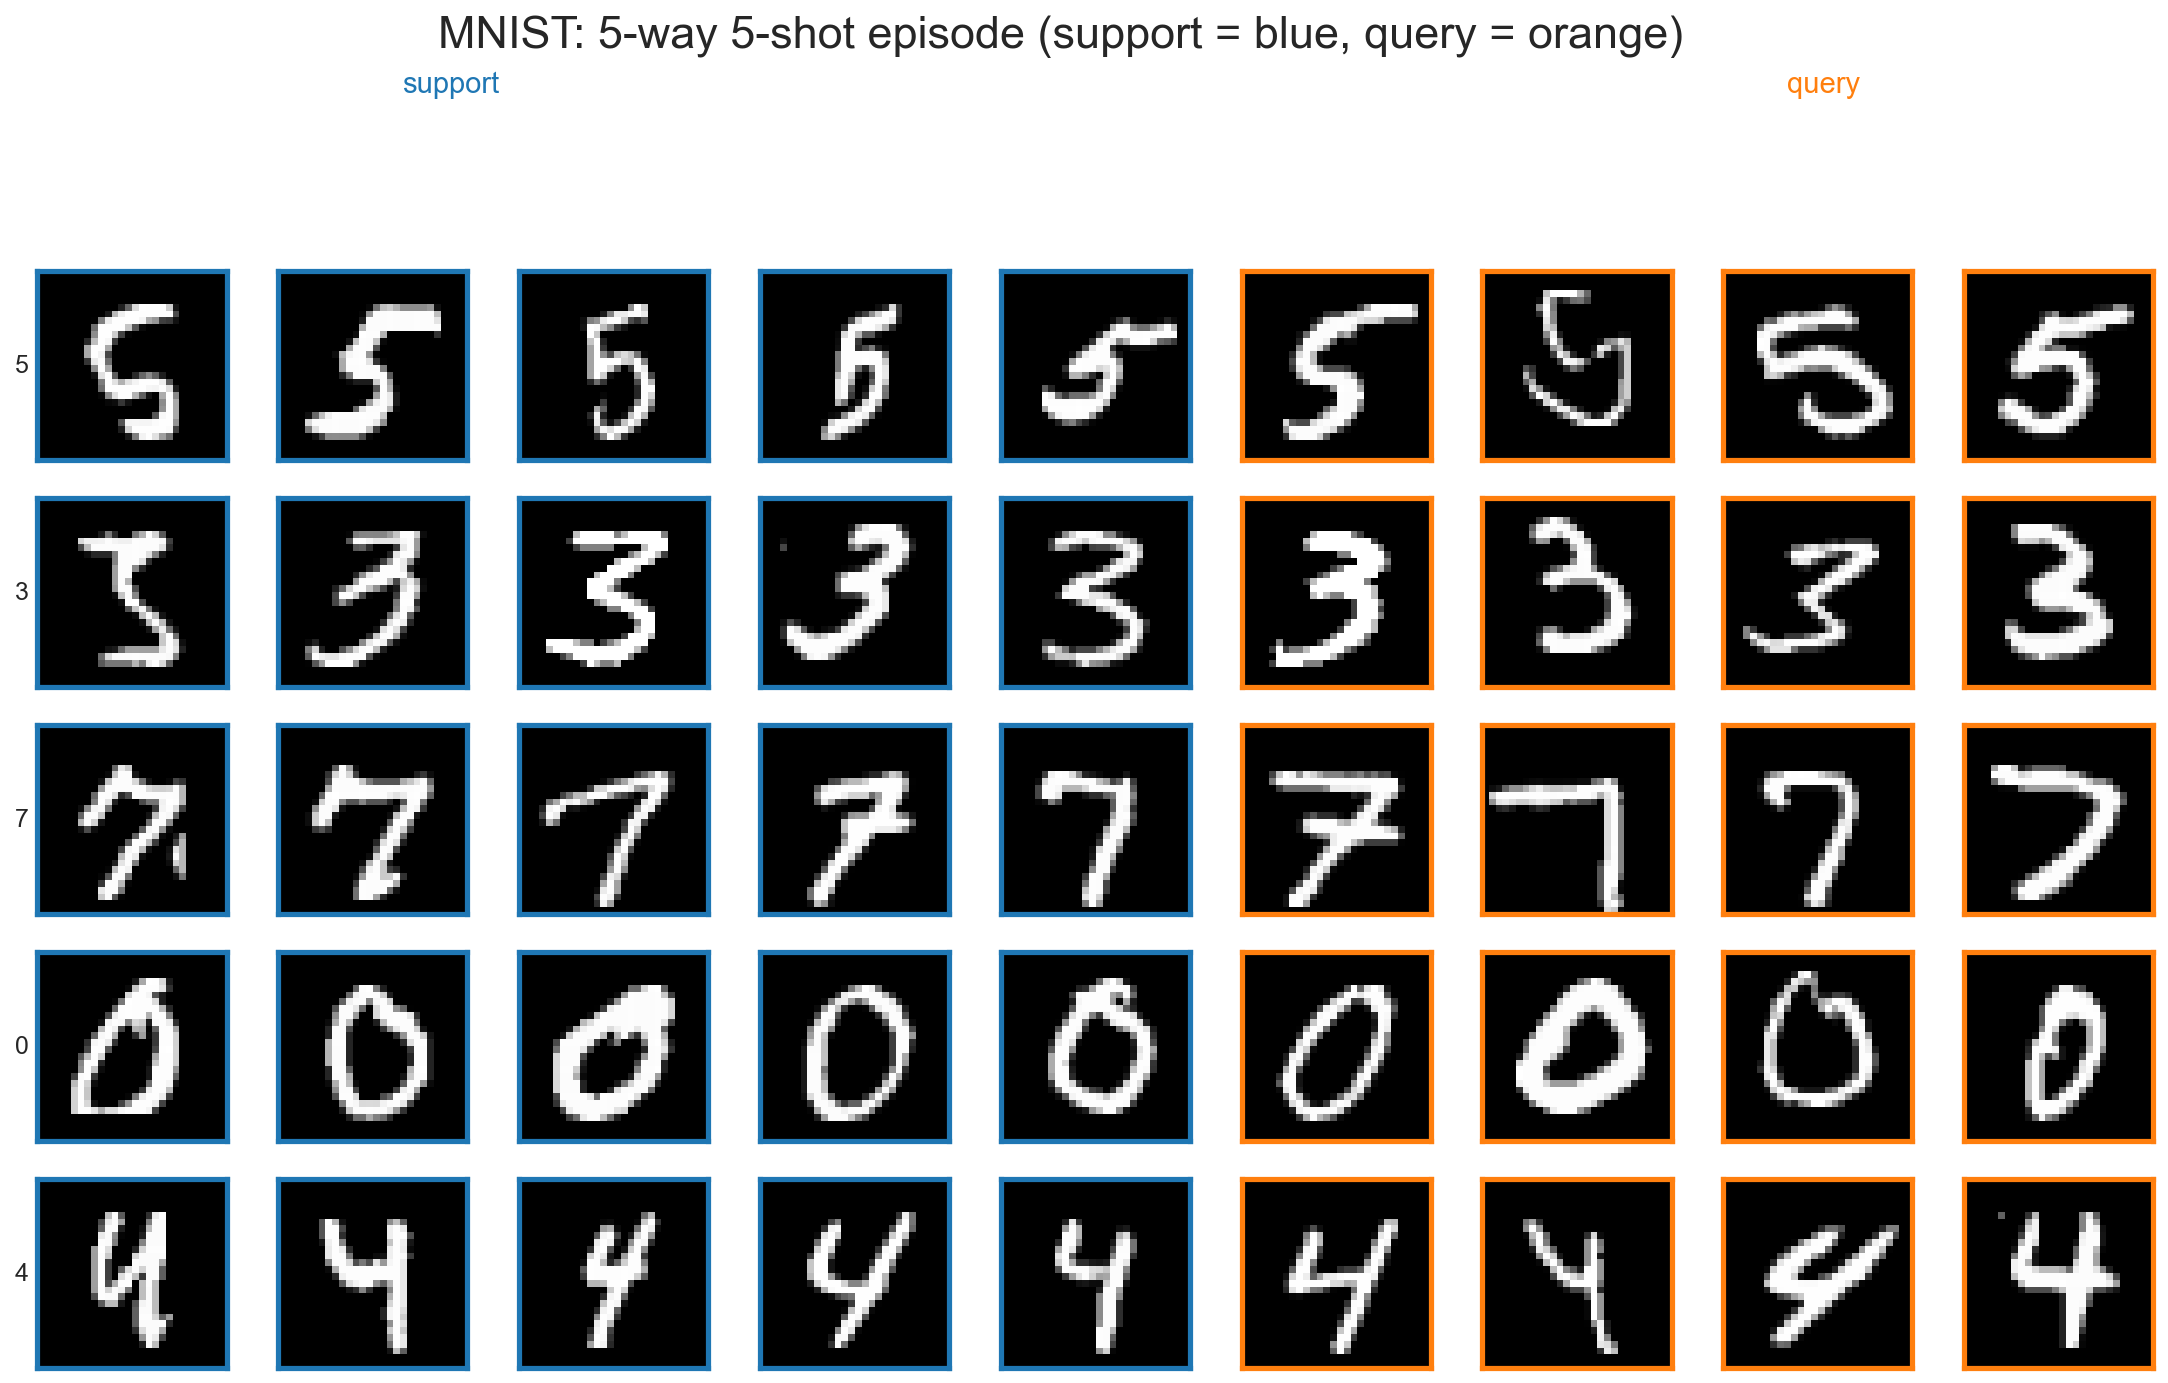

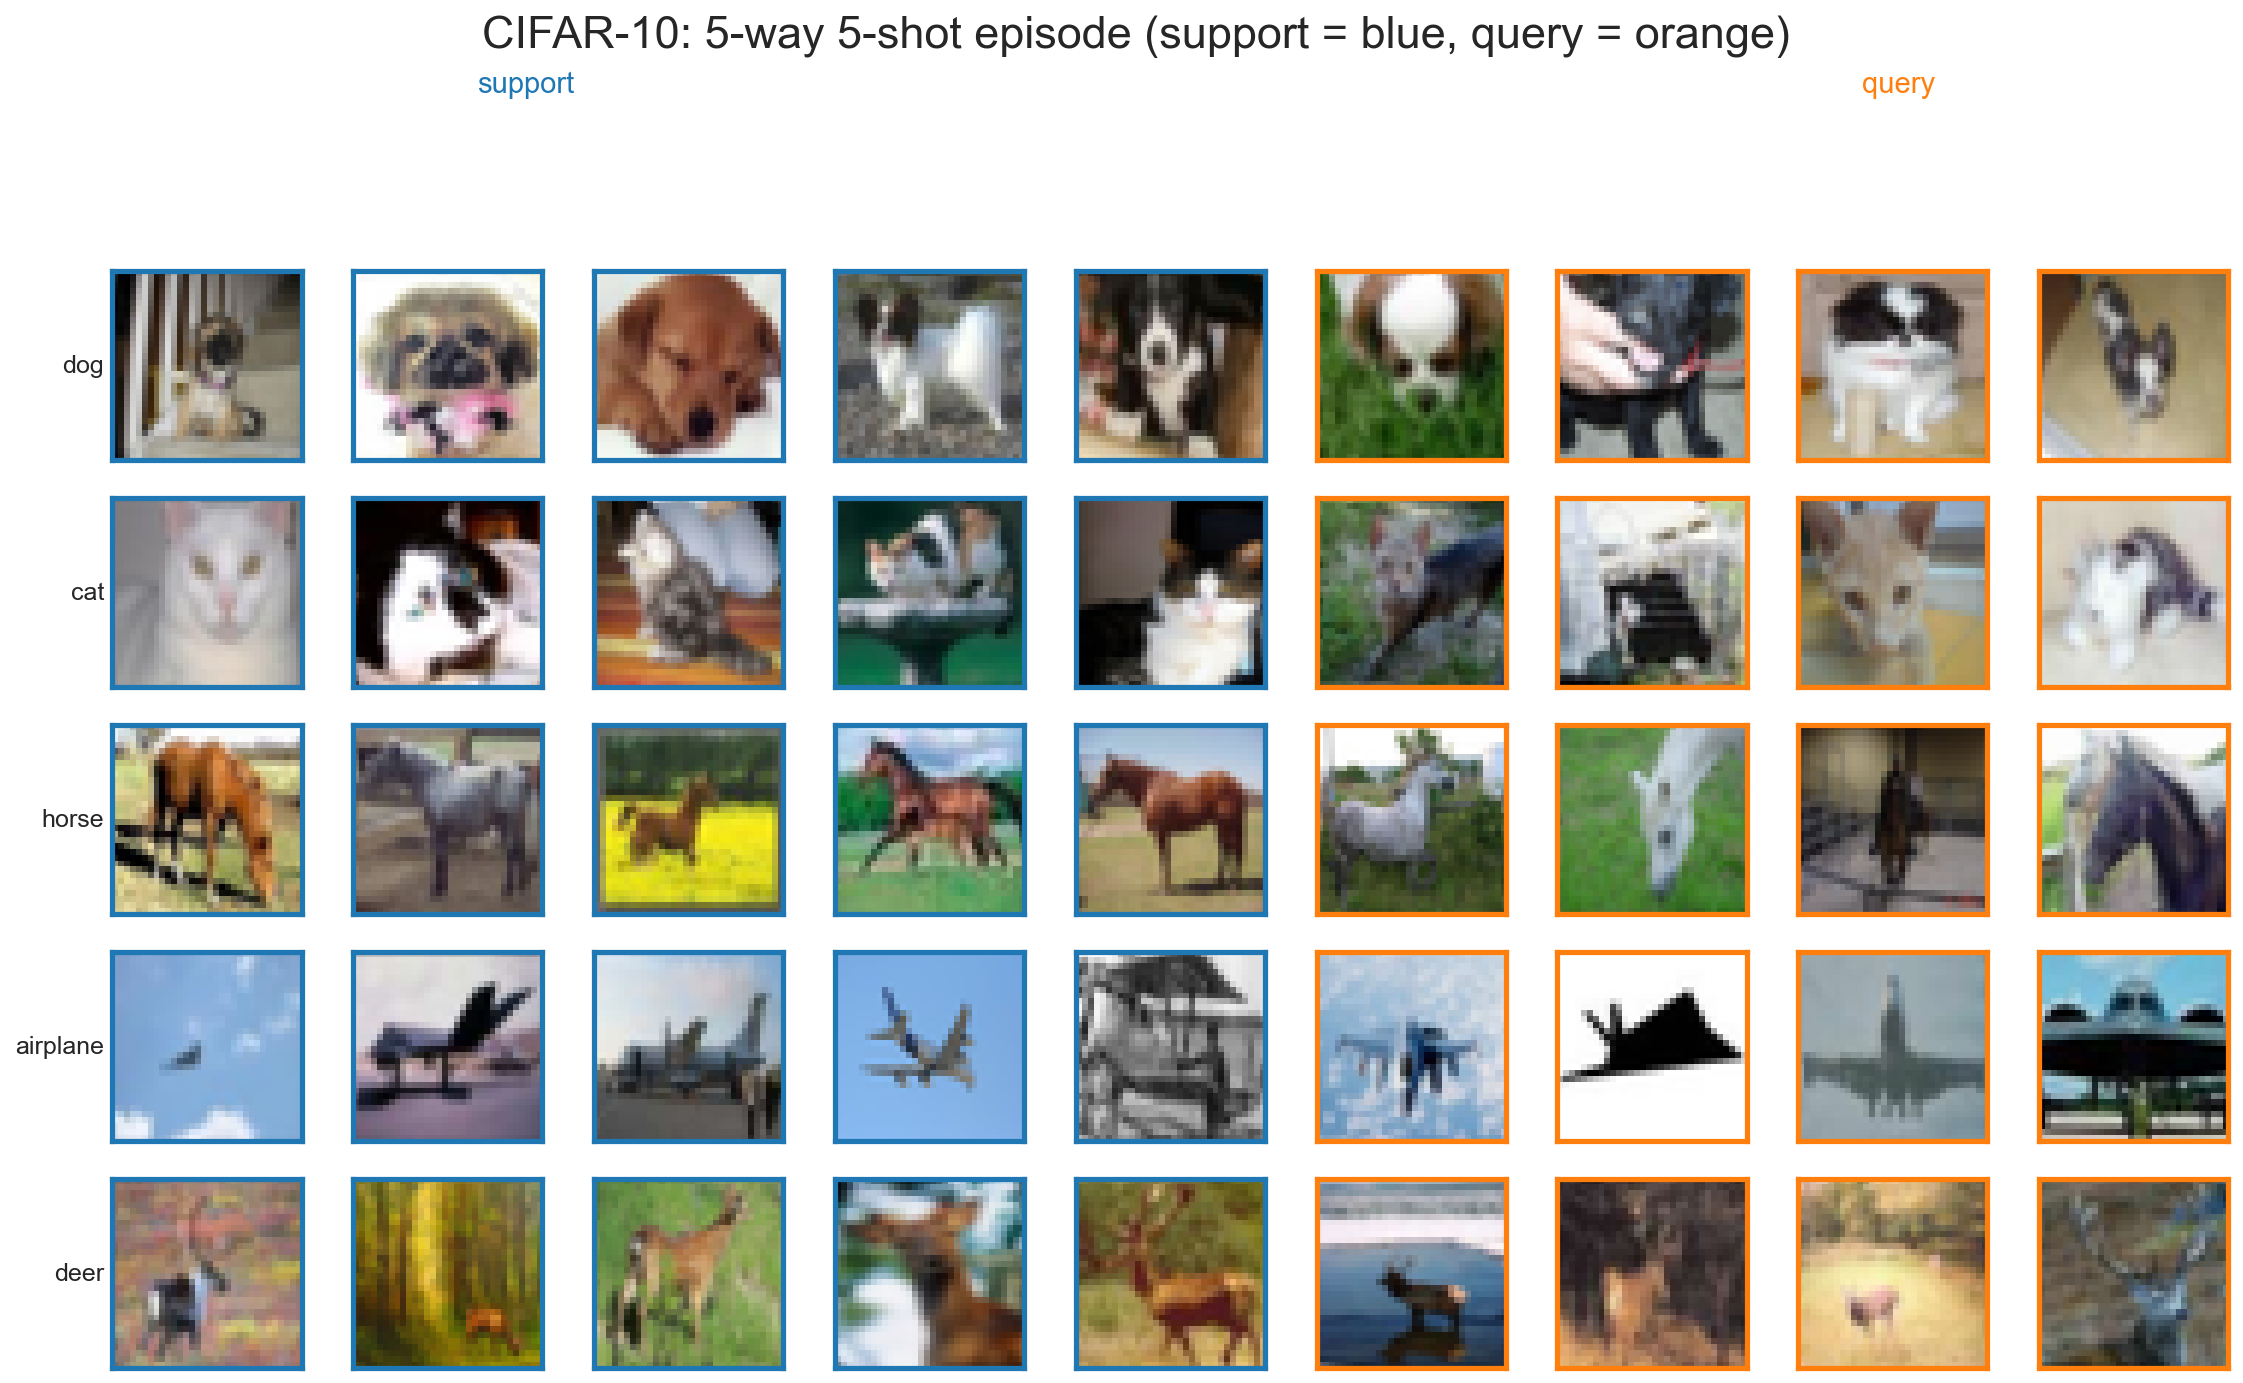

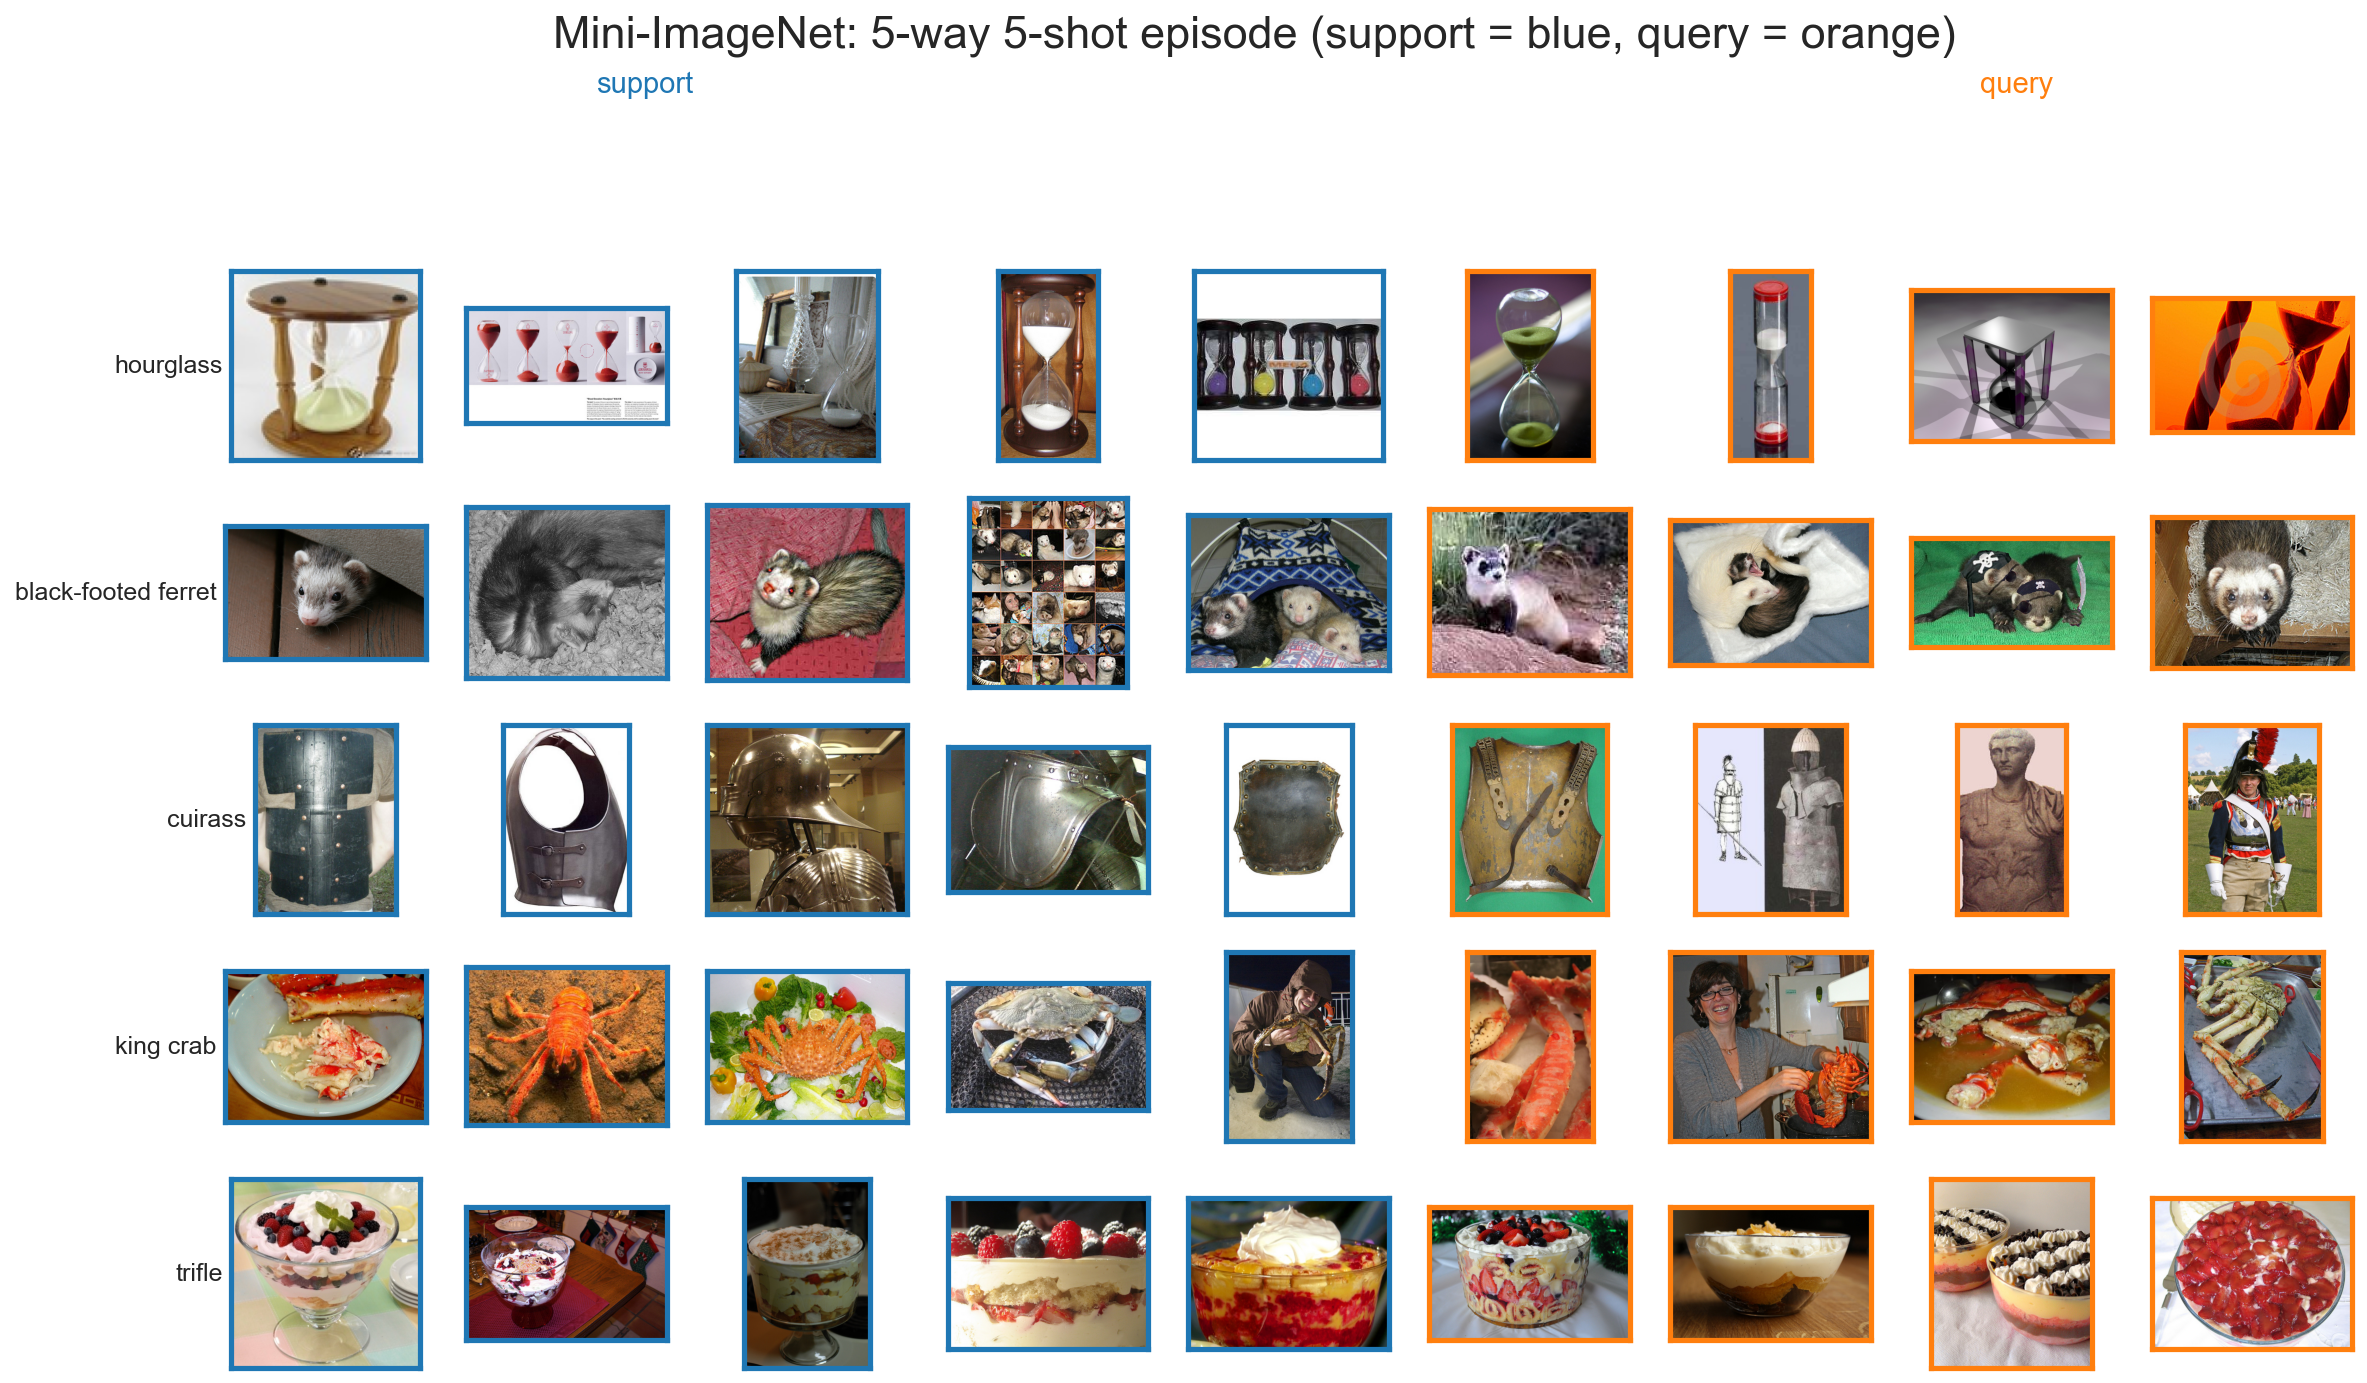

In [2]:
from IPython.display import Image, display

for ds in ("mnist", "cifar10", "mini_imagenet"):
    display(Image(str(REPO / "results" / "figures" / f"episode_grid_{ds}.png"), width=880))

## 3 · Embedding spaces

t-SNE of the frozen test embeddings per backbone (★ = class prototype). Class separation in these plots predicts few-shot performance: prototypes only work when frozen embeddings already cluster by class.

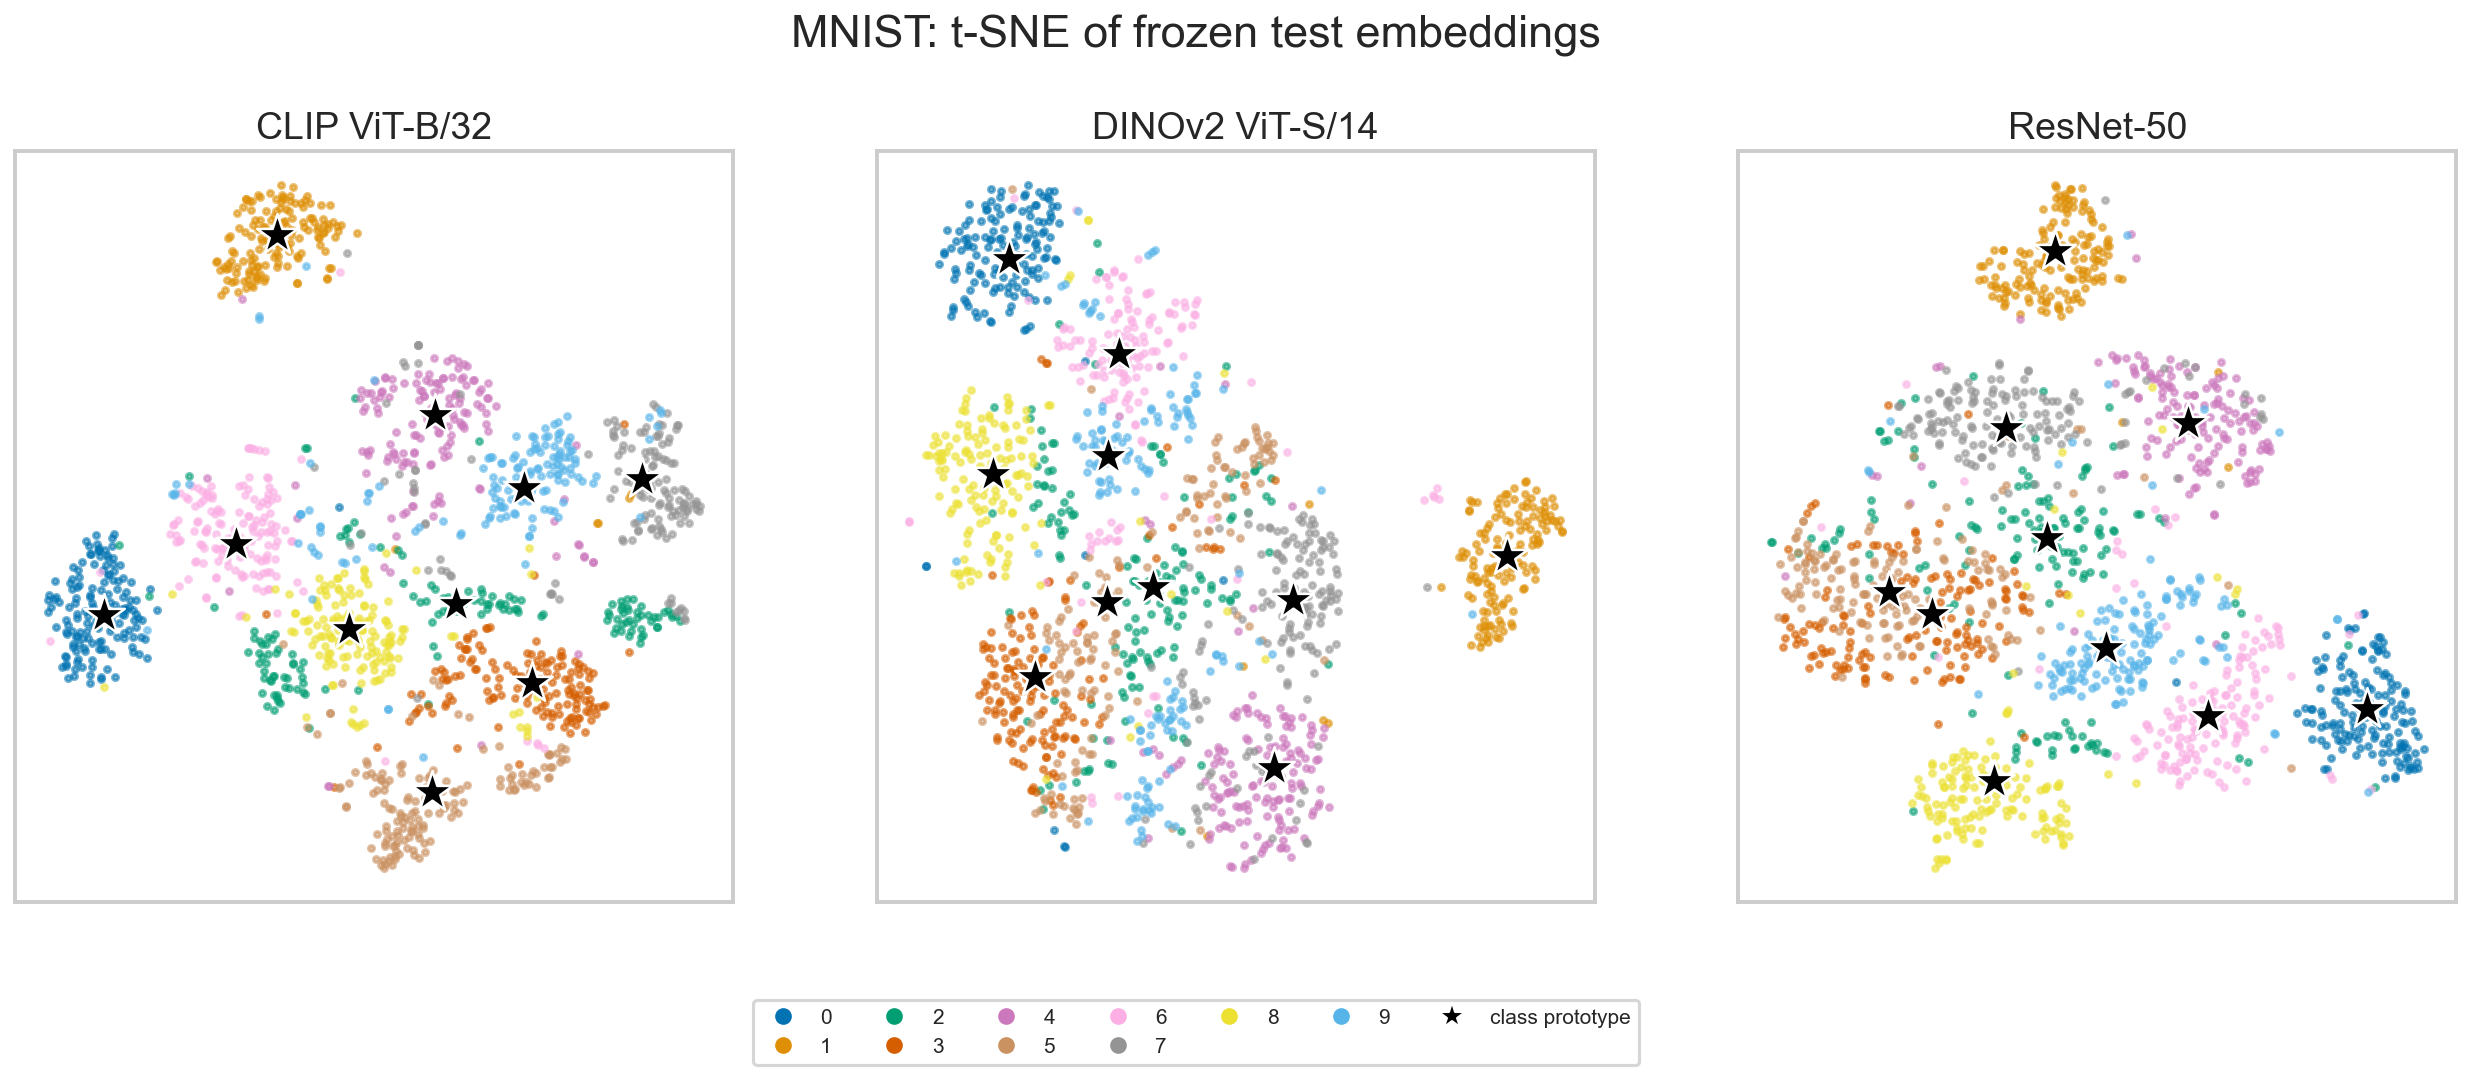

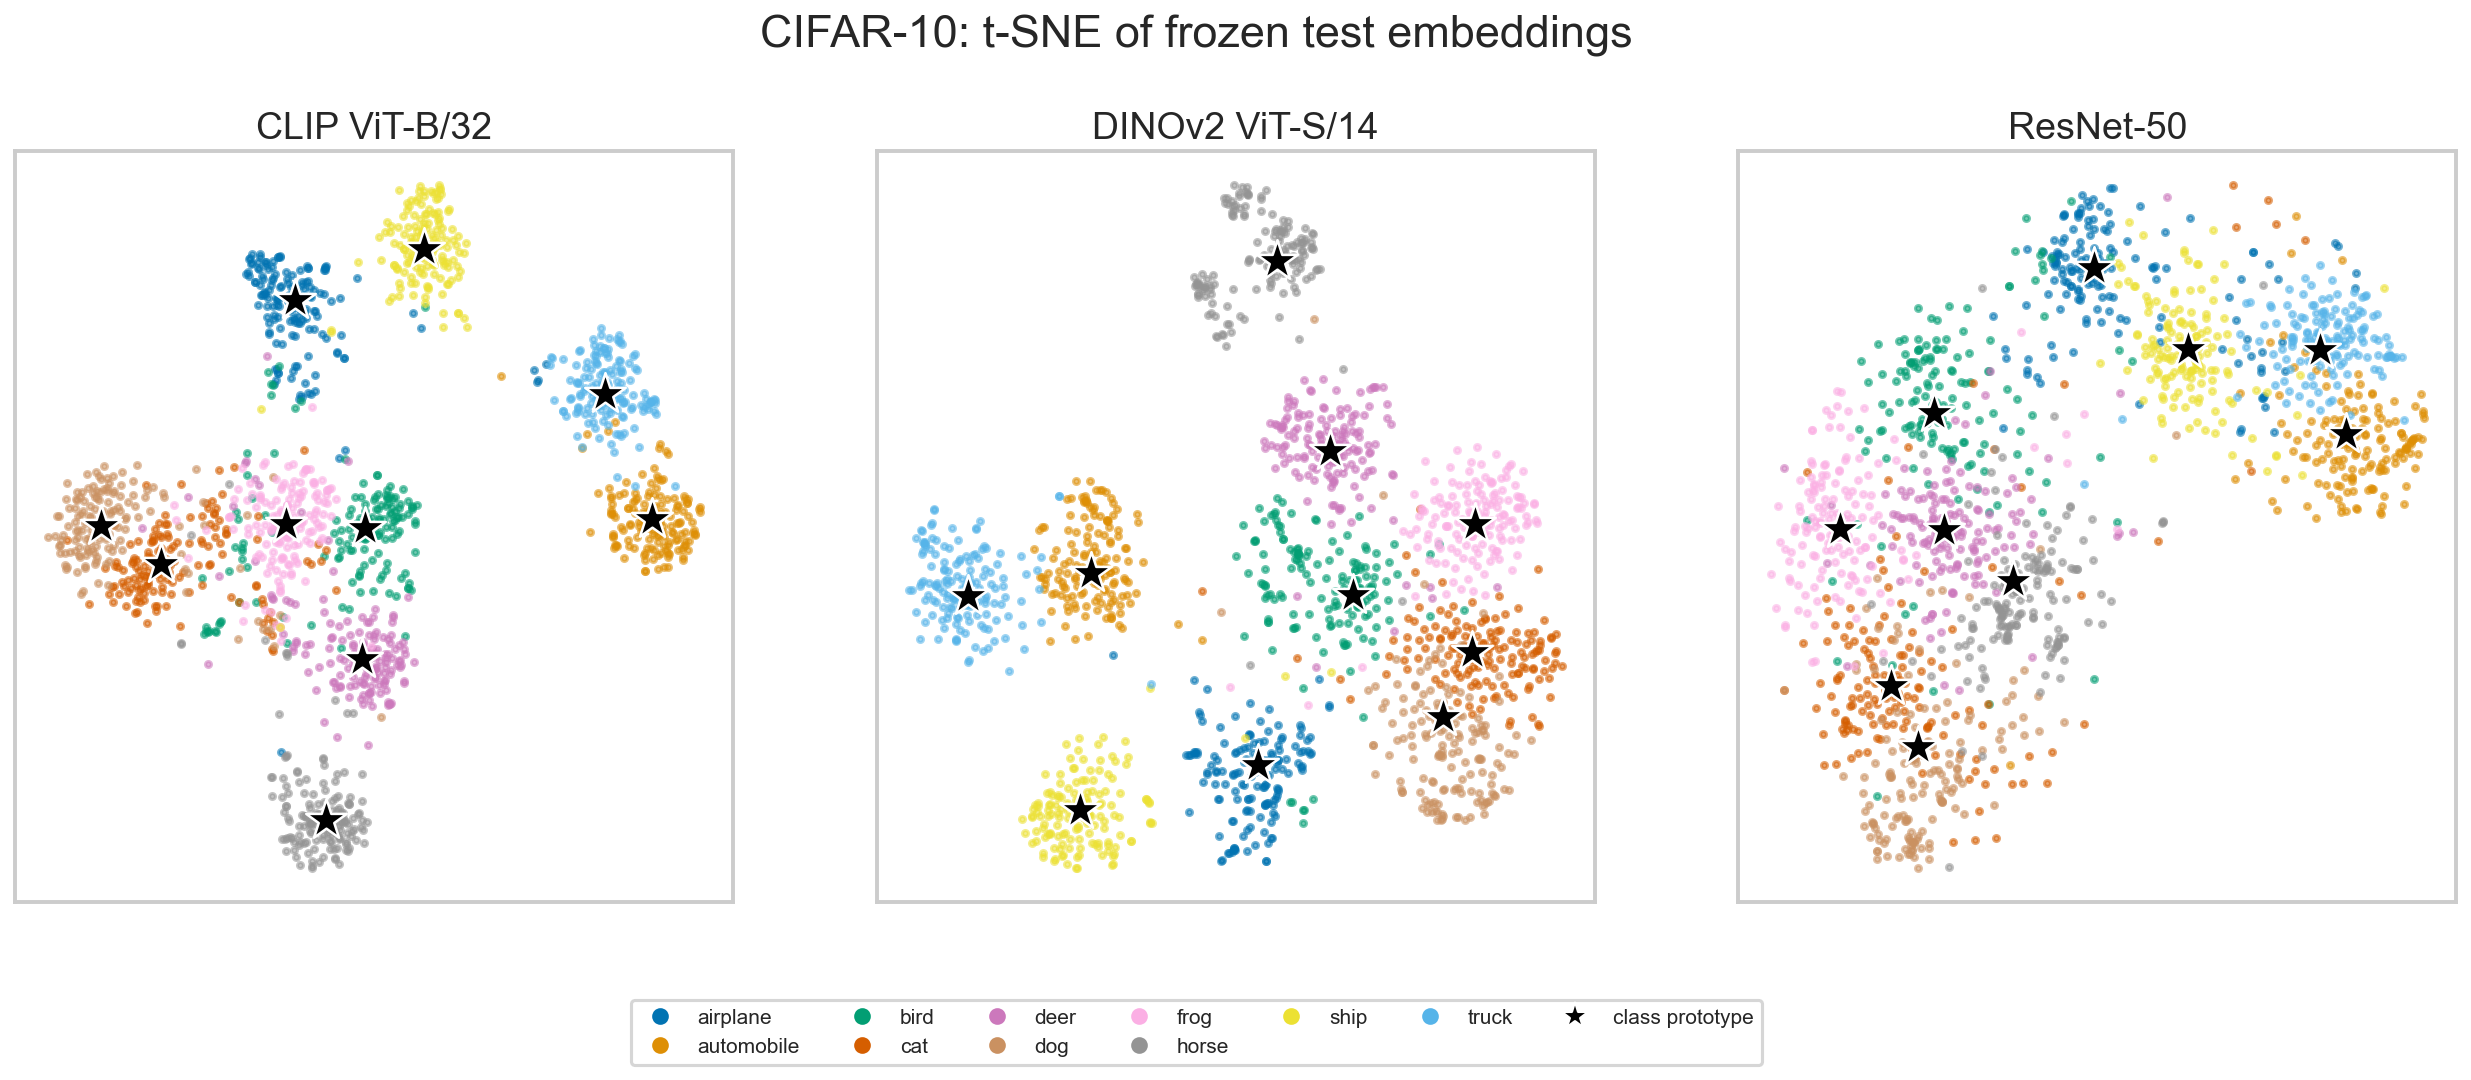

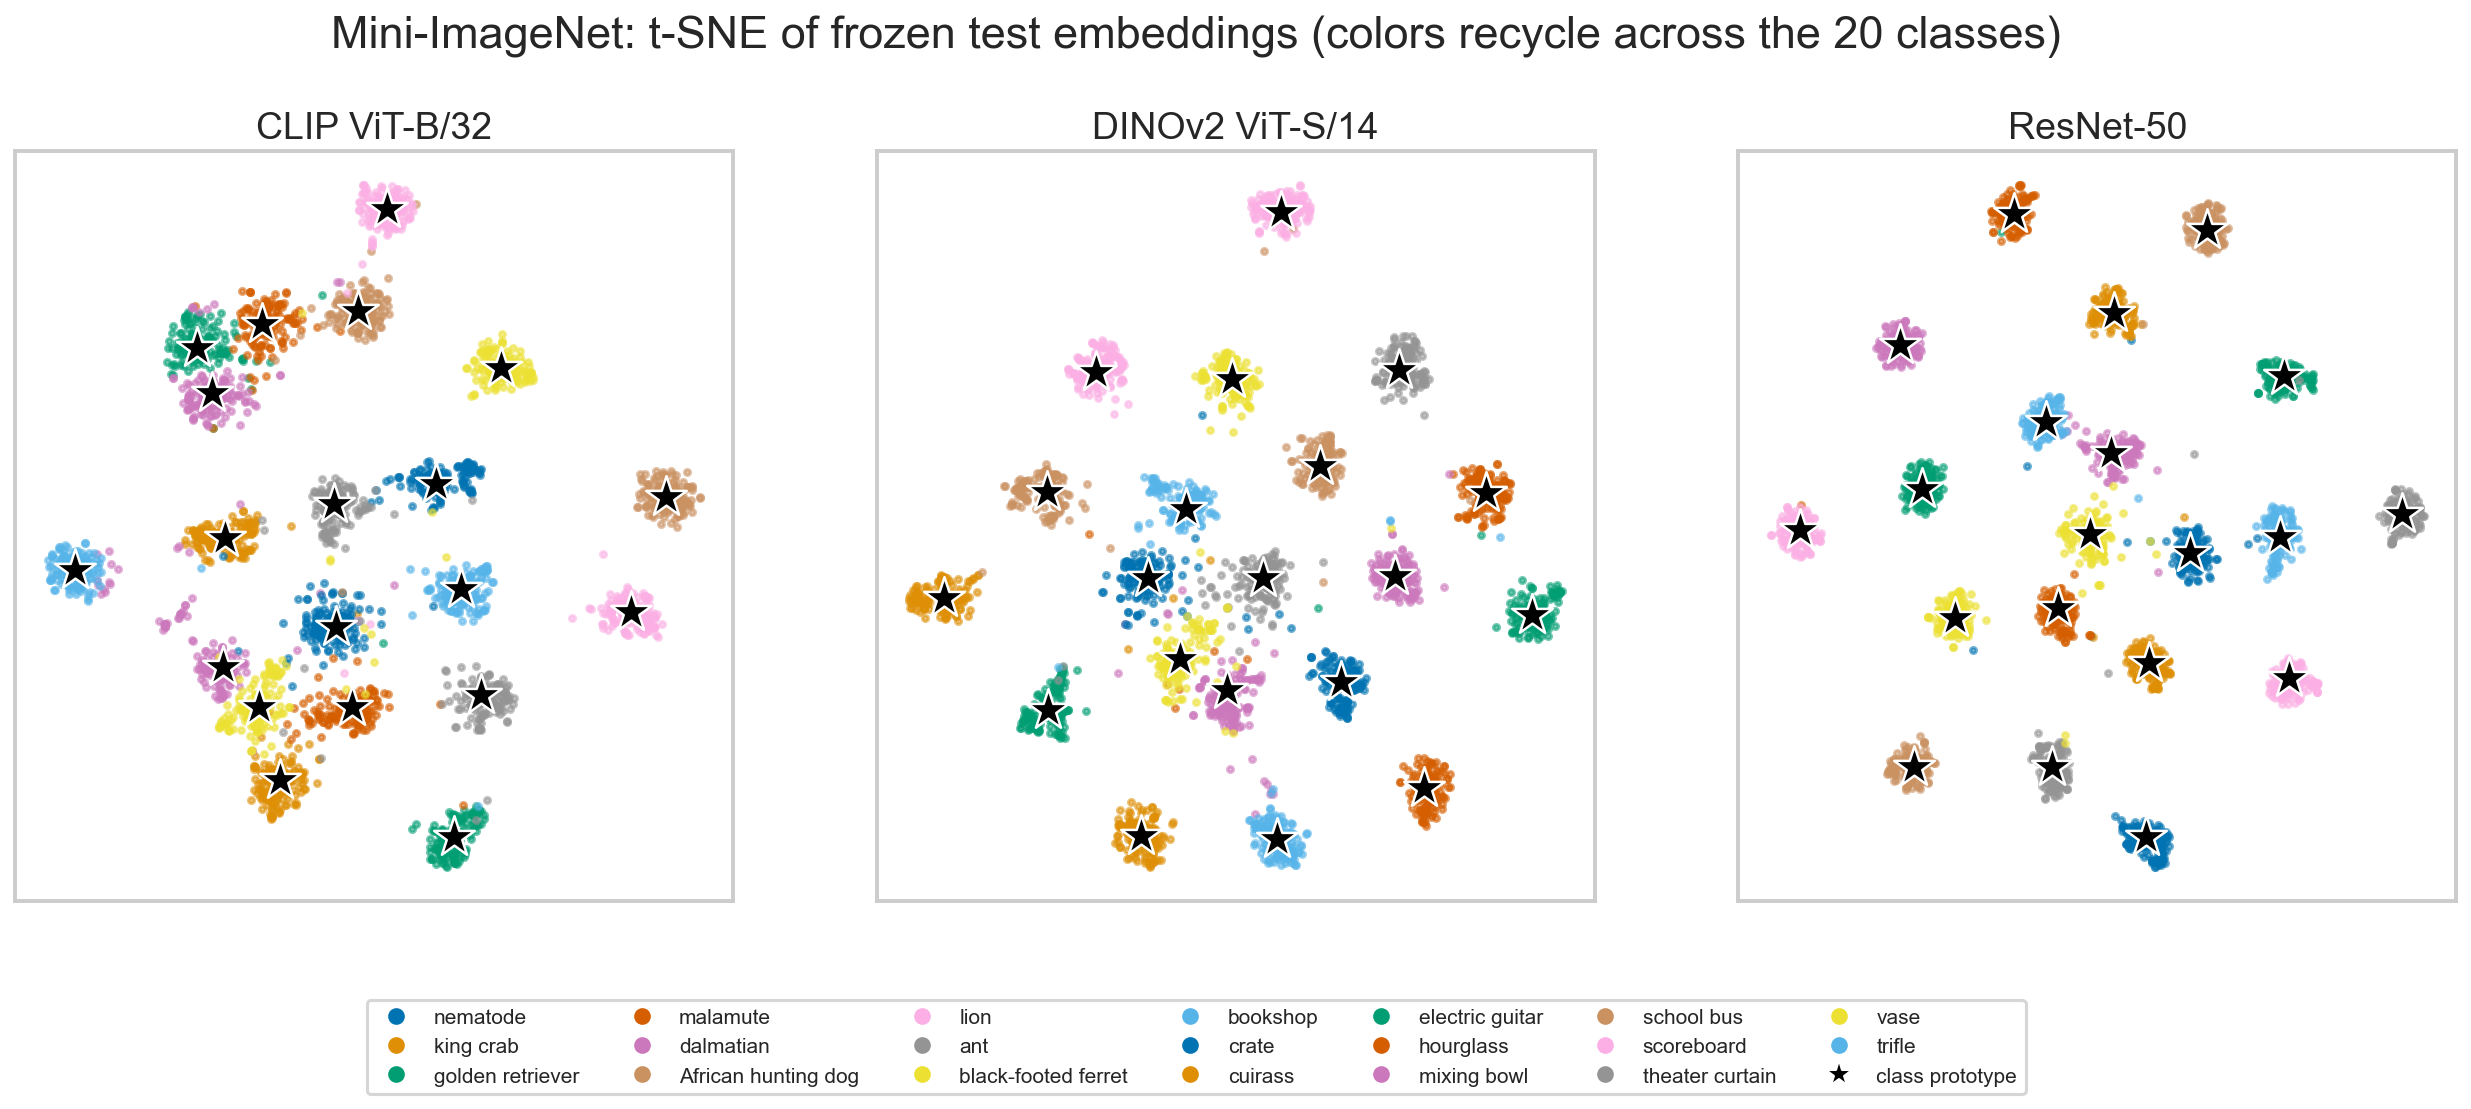

In [3]:
for ds in ("mnist", "cifar10", "mini_imagenet"):
    display(Image(str(REPO / "results" / "figures" / f"tsne_{ds}.png"), width=980))

## 4 · Classifiers

All heads share one interface — `predict(Xs, ys, Xq) → scores [B, Q, C]` over cached embeddings — and are pure torch (differentiable), so stage 2/3 can insert a Flow-Matching module upstream without touching evaluation.

**Prototype** — class prototype $c_k = \frac{1}{|S_k|}\sum_{x \in S_k} f(x)$; query scored by cosine similarity (primary) or negative squared Euclidean distance (ablation) to each prototype. No training.

**Linear probe** — `nn.Linear(dim, C)` + `CrossEntropyLoss`, Adam (300 steps, lr 0.01) on the support set only. Episodic evaluation trains all 600 episode heads jointly as a batched tensor `[600, C, dim]` — mathematically identical to 600 independent `nn.Linear` heads, ~100× faster.

**Zero-shot CLIP** — cached text embeddings of dataset-specific prompts (e.g. `'a photo of the number: "{}".'` for MNIST); query scored by image–text cosine similarity. Single-prompt vs. prompt-ensemble reported separately. In episodic mode only the 5 episode classes are scored.

## 5 · Results — episodic protocol (mean ± 95% CI, 600 episodes)

In [4]:
import pandas as pd

from src.visualize import method_label

pd.set_option("display.precision", 2)
ep = pd.read_csv(REPO / "results" / "metrics" / "episodic.csv")
ep["accuracy"] = (100 * ep["acc"]).round(2).astype(str) + " ± " + (100 * ep["ci95"]).round(2).astype(str)
ep["method"] = ep["classifier"].map(method_label)
for k in sorted(ep["k_shot"].unique()):
    t = ep[ep["k_shot"] == k].pivot(index="method", columns="dataset", values="accuracy")
    print(f"\n=== 5-way {k}-shot ===")
    display(t)


=== 5-way 1-shot ===


dataset,cifar10,mini_imagenet,mnist
method,,,
"Linear probe, CLIP",76.86 ± 0.8,91.4 ± 0.57,59.96 ± 0.86
"Prototype (cos), CLIP",72.92 ± 0.85,89.15 ± 0.64,56.56 ± 0.87
"Prototype (cos), DINOv2",77.34 ± 0.72,94.42 ± 0.47,56.54 ± 0.92
"Prototype (cos), ResNet-50",62.3 ± 0.76,97.38 ± 0.26,55.96 ± 0.82
"Prototype (eucl), CLIP",74.07 ± 0.82,90.09 ± 0.61,56.64 ± 0.87
"Prototype (eucl), DINOv2",75.3 ± 0.77,94.57 ± 0.47,56.76 ± 0.92
"Prototype (eucl), ResNet-50",57.12 ± 0.8,78.69 ± 1.13,55.79 ± 0.83
Zero-shot CLIP (1 prompt),93.14 ± 0.28,99.0 ± 0.1,59.61 ± 0.88
Zero-shot CLIP (ensemble),93.44 ± 0.27,99.08 ± 0.1,56.98 ± 0.89



=== 5-way 5-shot ===


dataset,cifar10,mini_imagenet,mnist
method,,,
"Linear probe, CLIP",90.82 ± 0.37,98.26 ± 0.16,86.6 ± 0.44
"Prototype (cos), CLIP",89.16 ± 0.42,97.7 ± 0.2,78.01 ± 0.6
"Prototype (cos), DINOv2",91.95 ± 0.37,98.56 ± 0.15,75.61 ± 0.67
"Prototype (cos), ResNet-50",81.68 ± 0.48,99.51 ± 0.08,76.86 ± 0.7
"Prototype (eucl), CLIP",89.23 ± 0.42,97.66 ± 0.2,77.93 ± 0.6
"Prototype (eucl), DINOv2",91.91 ± 0.36,98.01 ± 0.17,75.6 ± 0.67
"Prototype (eucl), ResNet-50",81.21 ± 0.48,99.29 ± 0.1,76.87 ± 0.69
Zero-shot CLIP (1 prompt),93.03 ± 0.28,99.02 ± 0.11,59.53 ± 0.89
Zero-shot CLIP (ensemble),93.22 ± 0.27,99.1 ± 0.1,55.96 ± 0.89


**How to read the next two charts:** zero-shot CLIP wins on both natural-image datasets but is the *worst* head on MNIST — the one dataset far from its training distribution. In the backbone chart, ResNet-50's Mini-ImageNet bar is inflated by ImageNet-label overlap (§6), not few-shot skill.

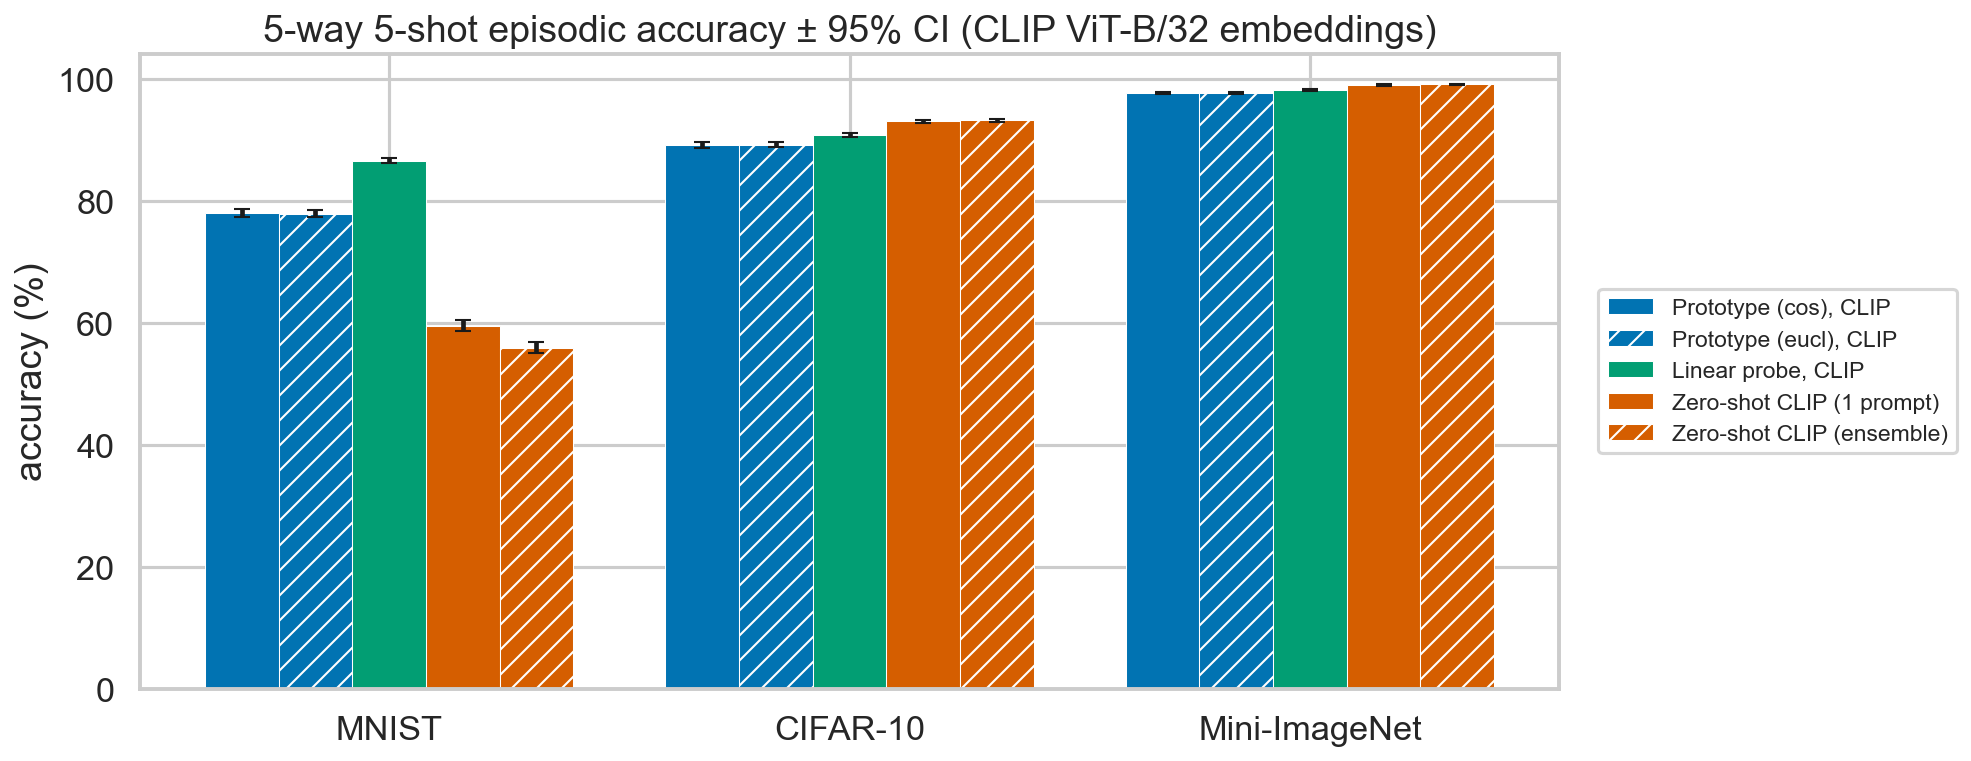

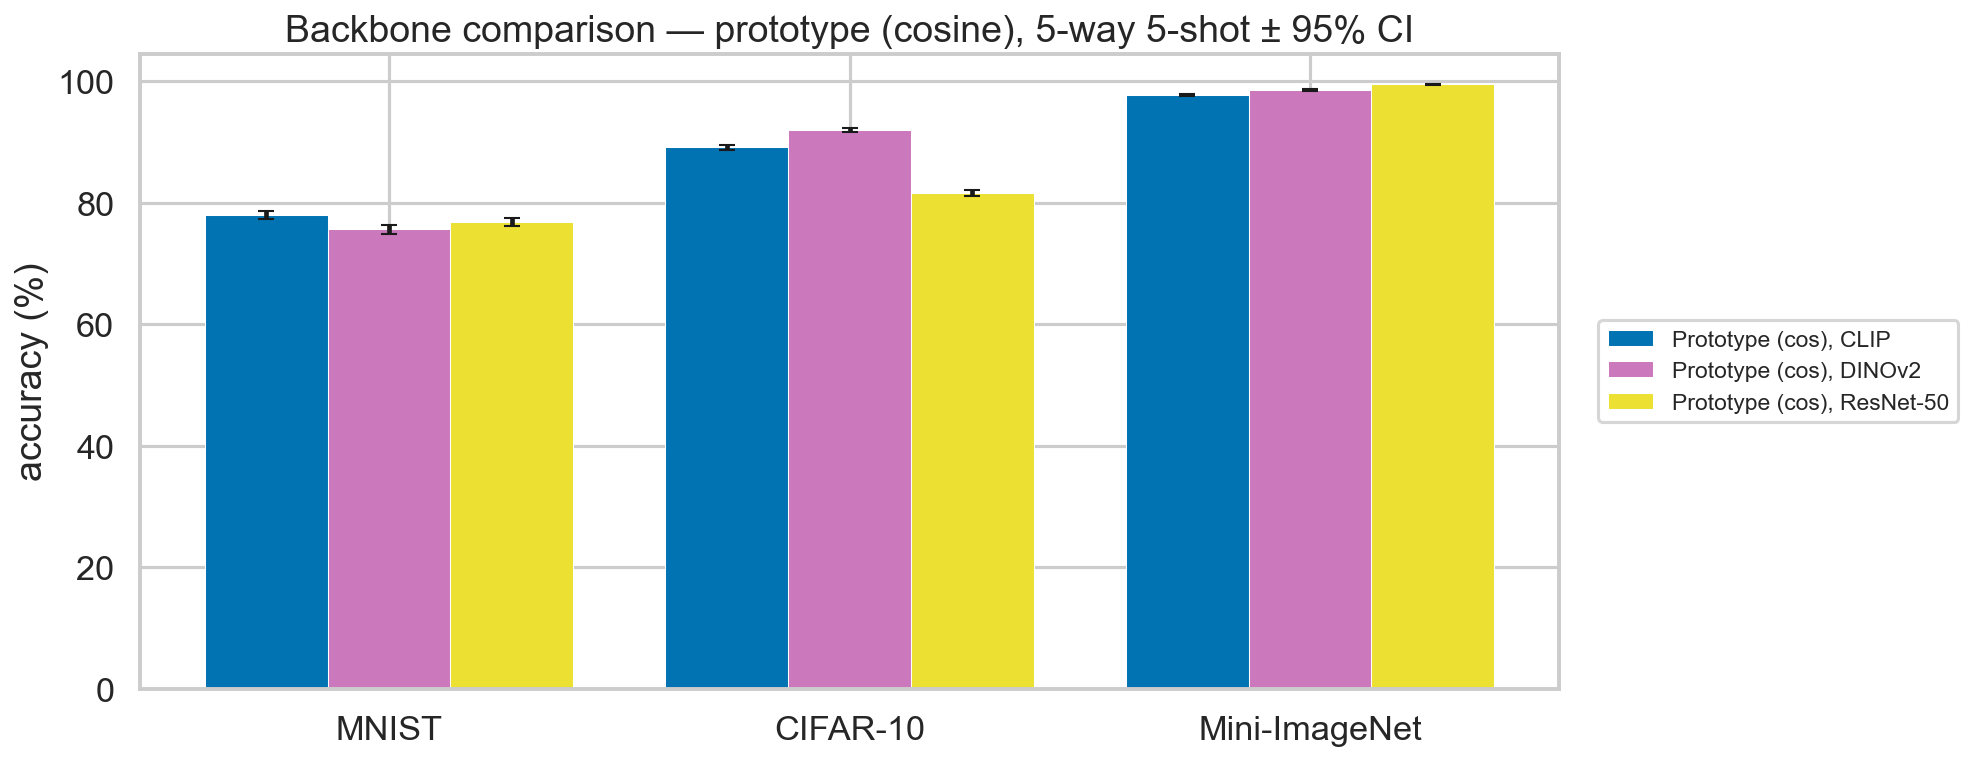

In [5]:
display(Image(str(REPO / "results" / "figures" / "bars_episodic_5shot.png"), width=880))
display(Image(str(REPO / "results" / "figures" / "bars_backbones.png"), width=880))

**Accuracy vs. shots:** watch the gap between the linear probe (green) and the prototype heads — it widens with K on MNIST but closes on CIFAR-10/Mini-ImageNet, where class means are already near-optimal at K=5.

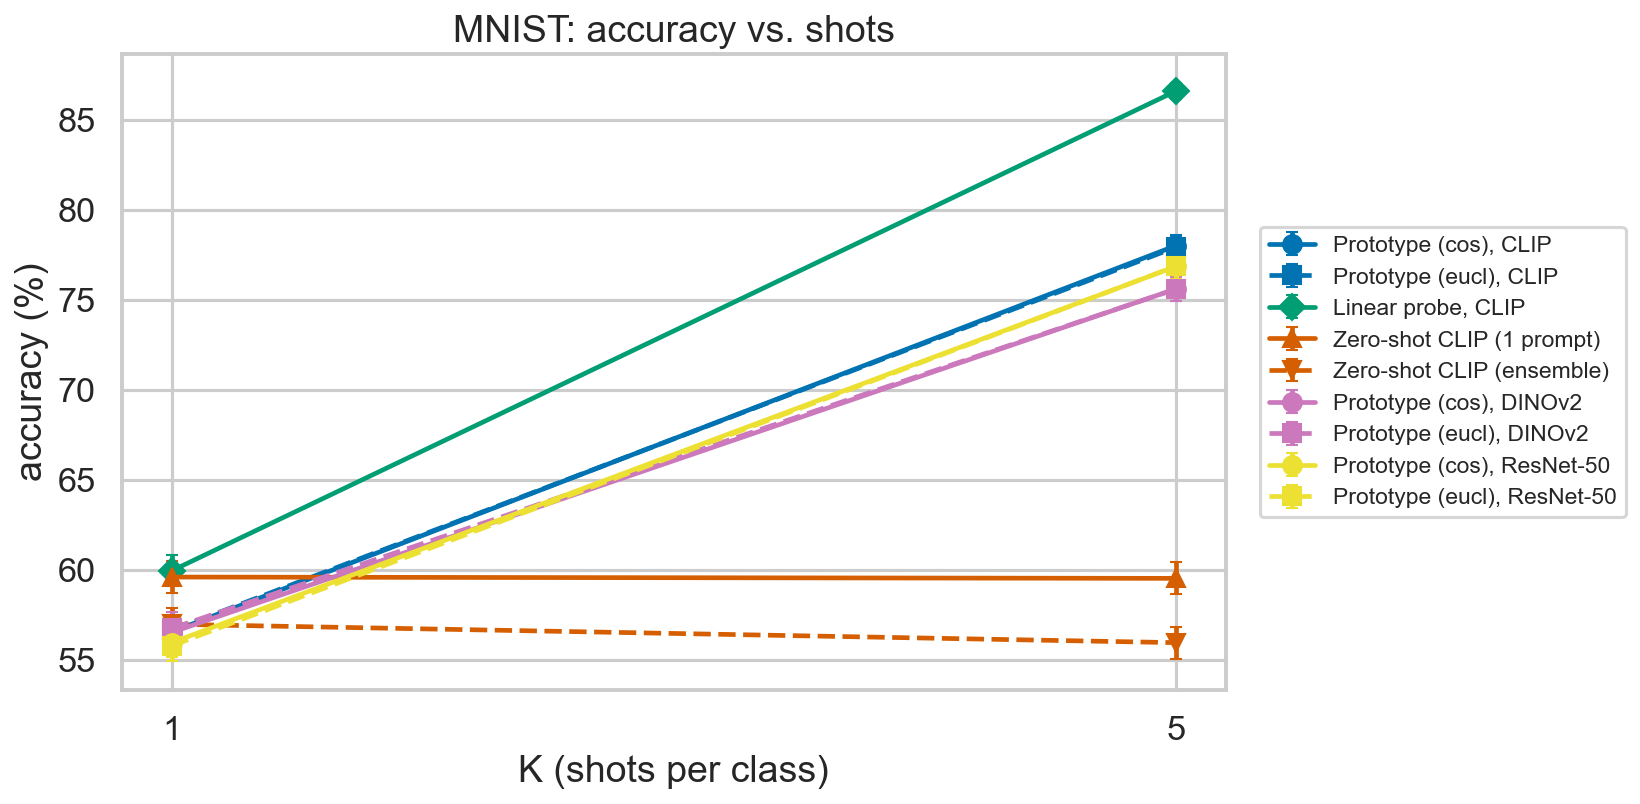

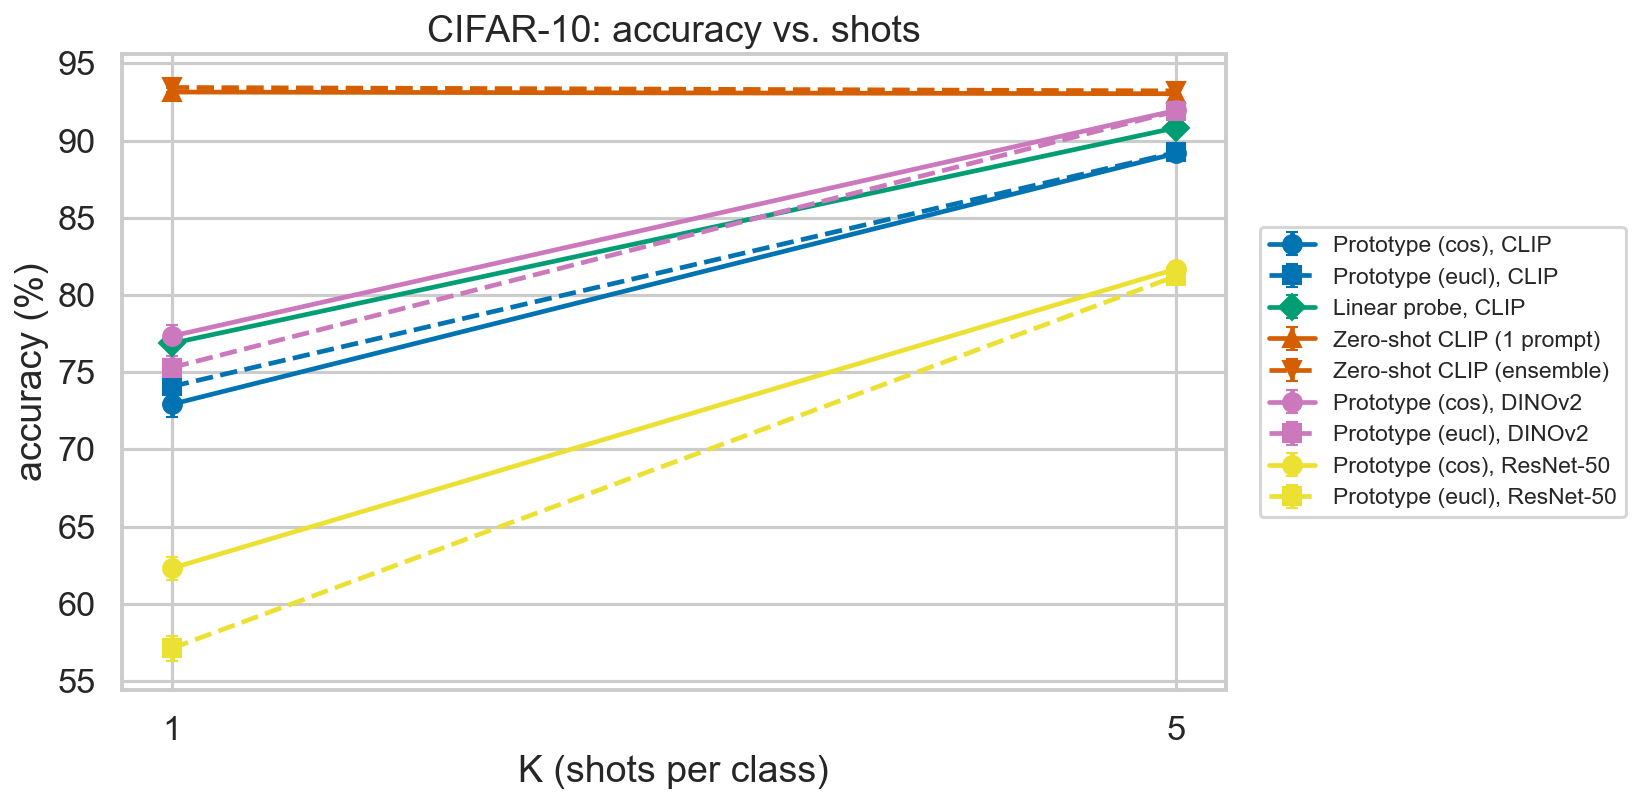

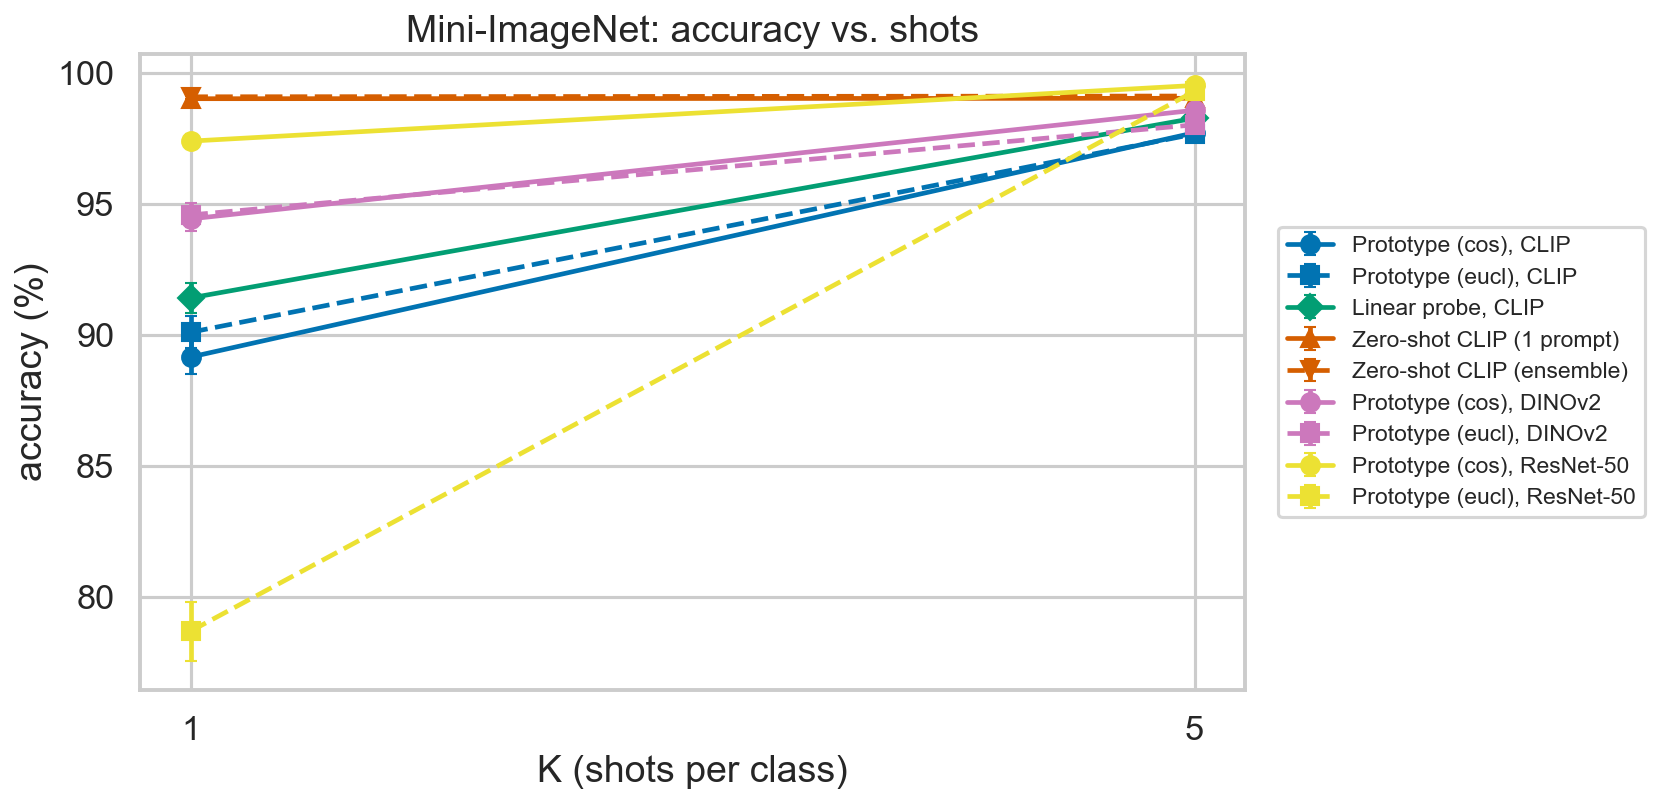

In [6]:
for ds in ("mnist", "cifar10", "mini_imagenet"):
    display(Image(str(REPO / "results" / "figures" / f"acc_vs_k_episodic_{ds}.png"), width=820))

## 5b · Results — simple all-classes protocol (mean ± std, 10 seeds)


=== mnist (all classes, full test set; k_shot=0 = zero-shot) ===


k_shot,0,1,5,10
method,,,,
"Linear probe, CLIP",NaN,49.95 ± 5.47,79.7 ± 1.41,88.62 ± 1.41
"Prototype (cos), CLIP",NaN,44.31 ± 5.75,66.53 ± 2.7,73.32 ± 1.88
"Prototype (cos), DINOv2",NaN,44.17 ± 4.16,64.1 ± 4.23,70.08 ± 1.57
"Prototype (cos), ResNet-50",NaN,43.16 ± 6.06,64.69 ± 4.73,72.68 ± 3.01
"Prototype (eucl), CLIP",NaN,44.6 ± 5.66,66.37 ± 2.72,73.22 ± 1.95
"Prototype (eucl), DINOv2",NaN,44.52 ± 4.14,64.1 ± 4.19,70.03 ± 1.62
"Prototype (eucl), ResNet-50",NaN,42.96 ± 5.88,64.84 ± 4.63,72.7 ± 3.01
Zero-shot CLIP (1 prompt),48.25 ± 0.0,NaN,NaN,NaN
Zero-shot CLIP (ensemble),47.4 ± 0.0,NaN,NaN,NaN



=== cifar10 (all classes, full test set; k_shot=0 = zero-shot) ===


k_shot,0,1,5,10
method,,,,
"Linear probe, CLIP",NaN,66.69 ± 4.59,86.37 ± 1.36,88.93 ± 0.79
"Prototype (cos), CLIP",NaN,61.07 ± 6.01,83.05 ± 1.84,86.26 ± 1.8
"Prototype (cos), DINOv2",NaN,65.36 ± 3.95,87.48 ± 1.62,90.25 ± 0.76
"Prototype (cos), ResNet-50",NaN,48.59 ± 3.03,69.28 ± 2.26,75.25 ± 2.16
"Prototype (eucl), CLIP",NaN,62.36 ± 5.48,83.02 ± 1.88,86.25 ± 1.72
"Prototype (eucl), DINOv2",NaN,62.53 ± 4.22,87.69 ± 1.51,90.22 ± 0.88
"Prototype (eucl), ResNet-50",NaN,42.91 ± 3.41,68.83 ± 2.31,75.07 ± 2.42
Zero-shot CLIP (1 prompt),88.31 ± 0.0,NaN,NaN,NaN
Zero-shot CLIP (ensemble),88.75 ± 0.0,NaN,NaN,NaN


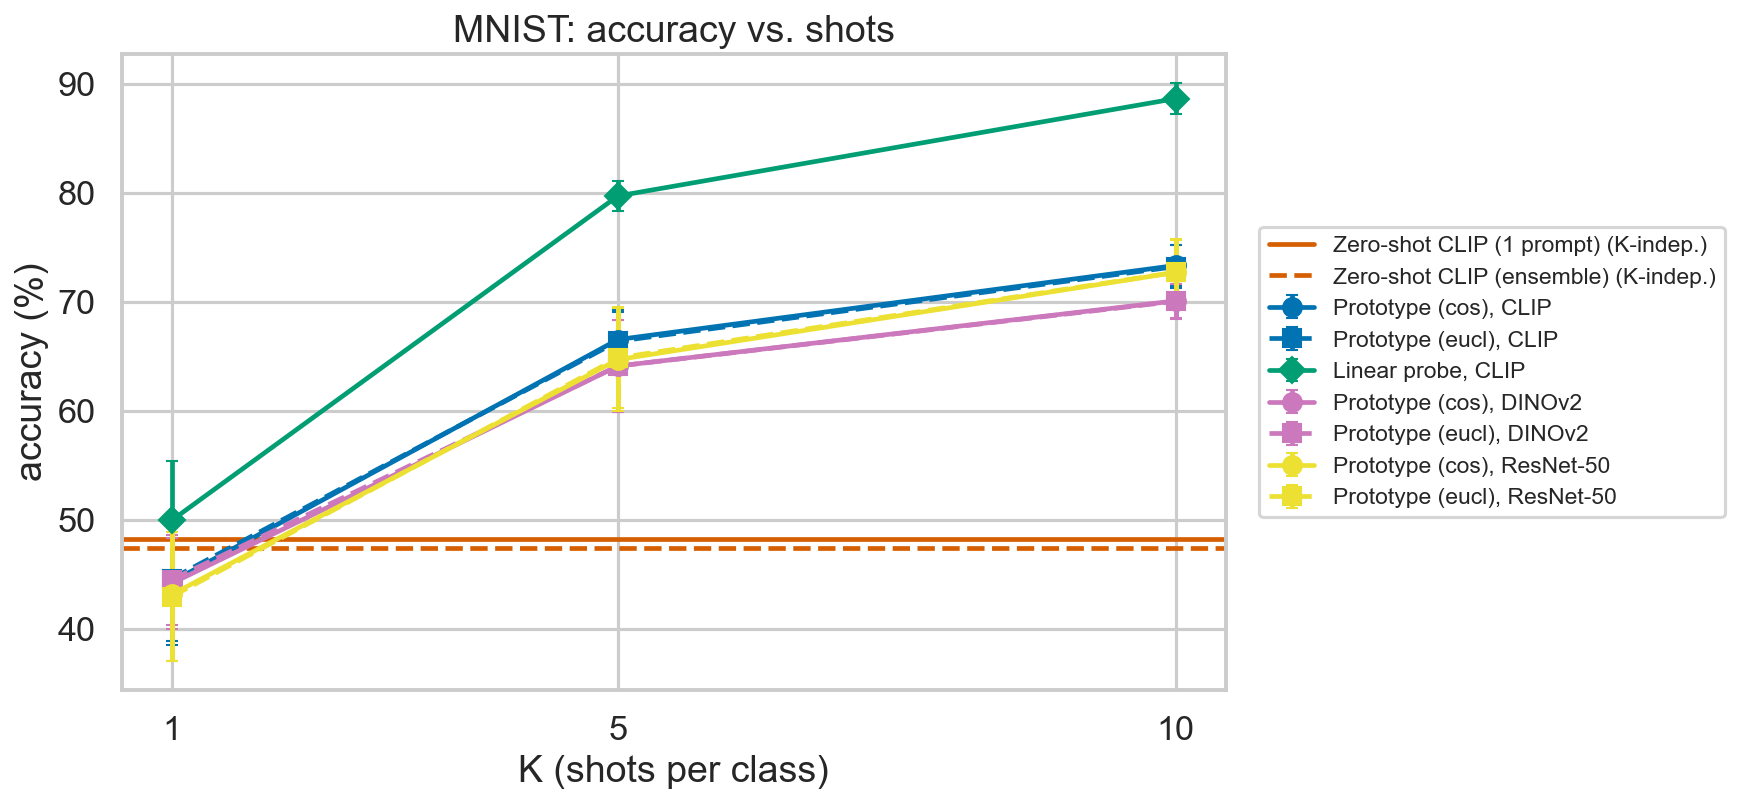

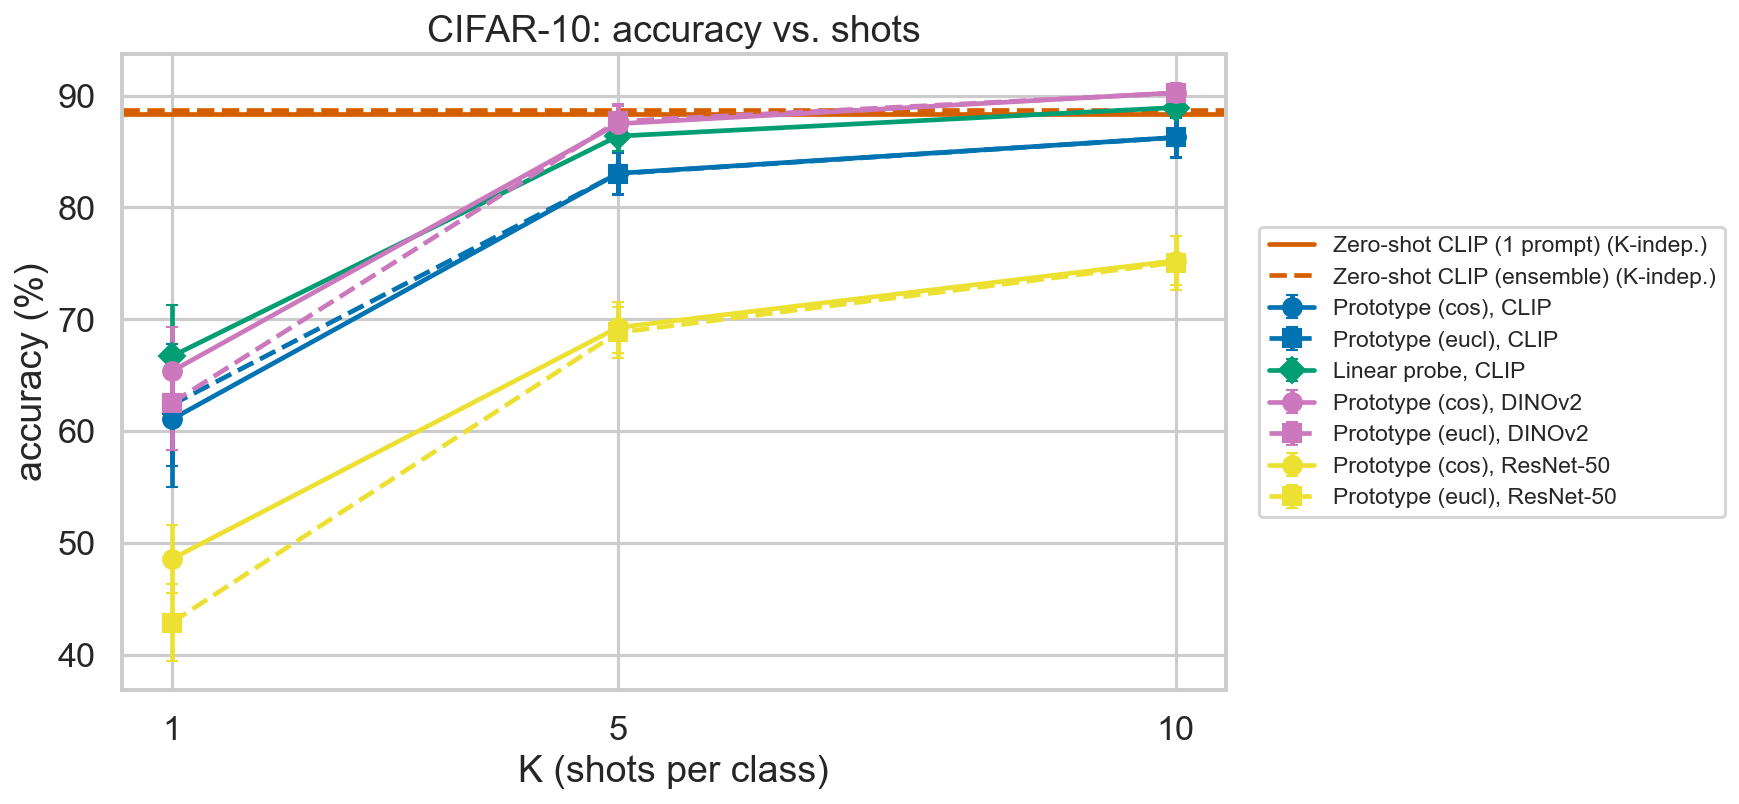

In [7]:
si = pd.read_csv(REPO / "results" / "metrics" / "simple.csv")
si["accuracy"] = (100 * si["acc"]).round(2).astype(str) + " ± " + (100 * si["std"]).round(2).astype(str)
si["method"] = si["classifier"].map(method_label)
for ds in ("mnist", "cifar10"):
    t = si[si["dataset"] == ds].pivot(index="method", columns="k_shot", values="accuracy")
    print(f"\n=== {ds} (all classes, full test set; k_shot=0 = zero-shot) ===")
    display(t)
for ds in ("mnist", "cifar10"):
    display(Image(str(REPO / "results" / "figures" / f"acc_vs_k_simple_{ds}.png"), width=820))

### Qualitative results

The confusion matrices show *where* the prototype head fails: 2/7/9 on MNIST, the cat↔dog and bird↔deer pairs on CIFAR-10. The zero-shot panels show the *least confident* CLIP predictions — even the hardest cases are two-way ambiguities. The failure galleries show the most confident misclassification per (true, predicted) pair.

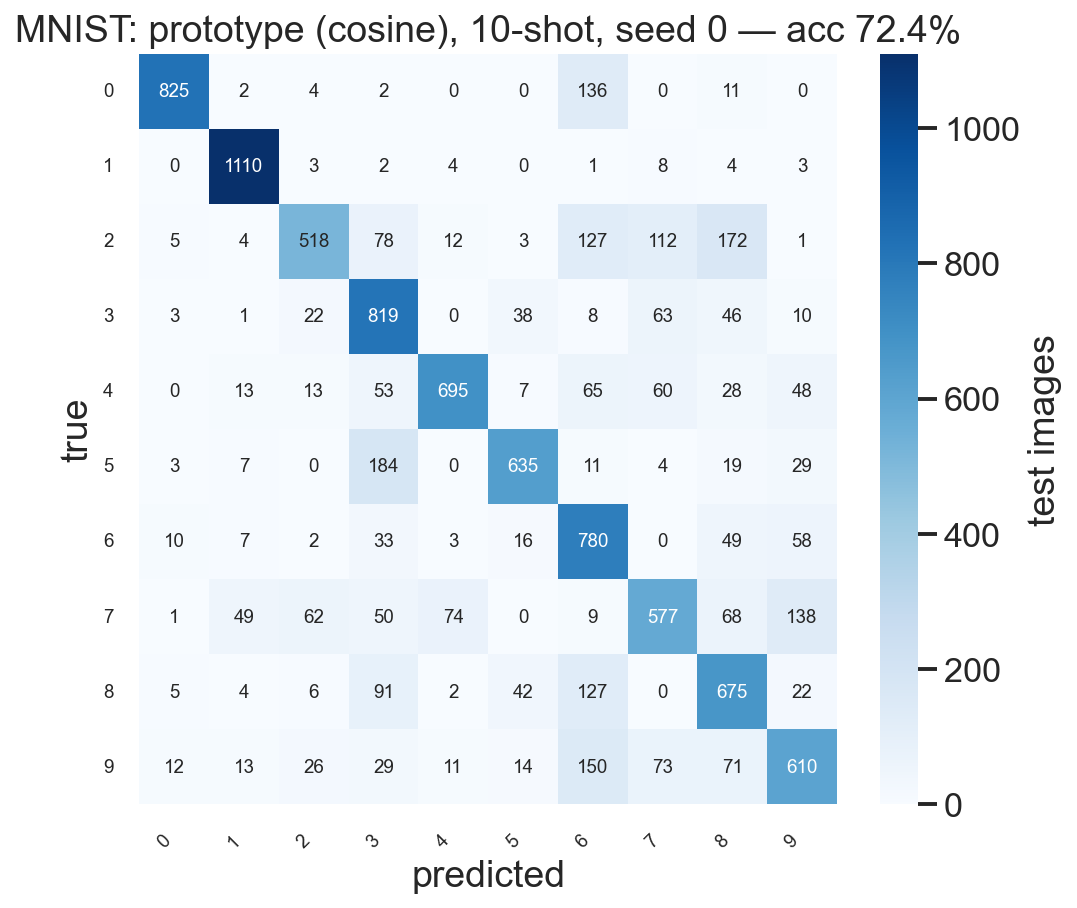

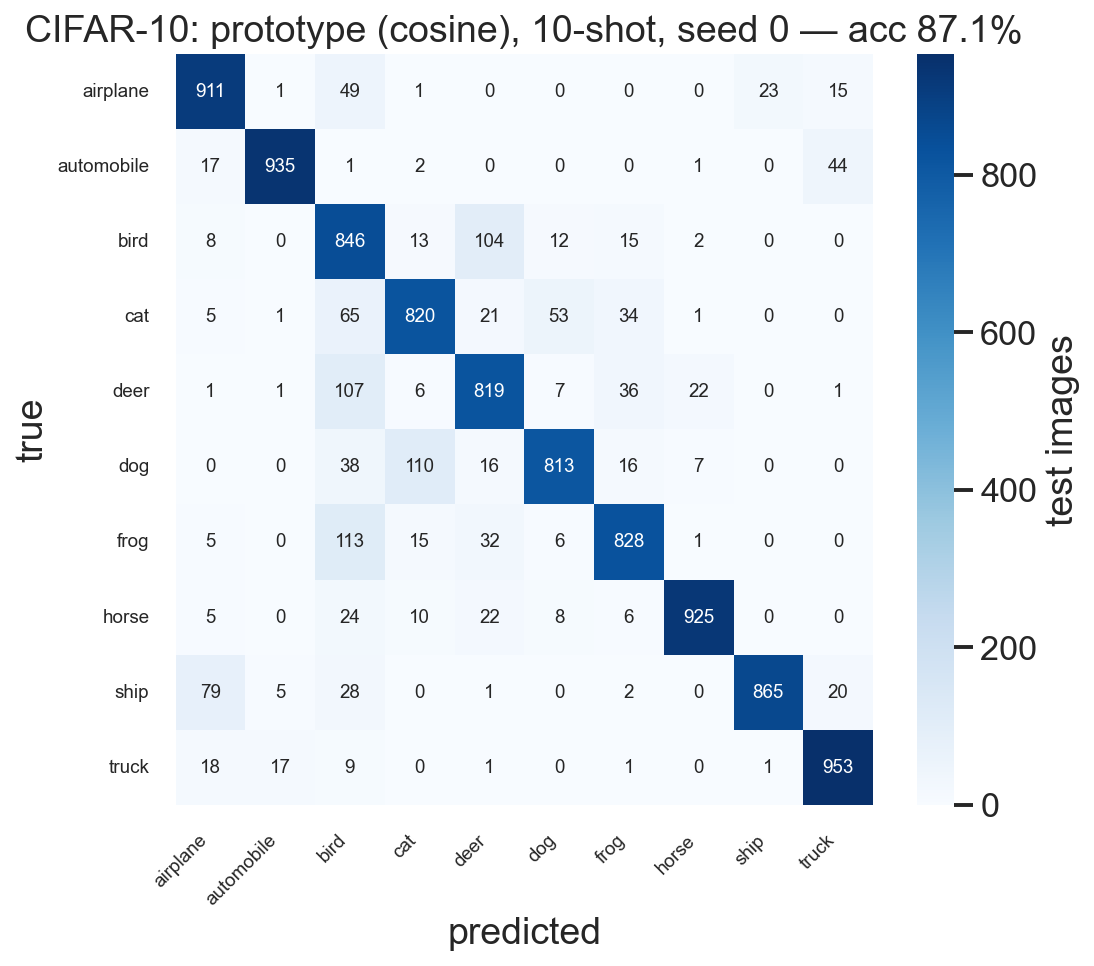

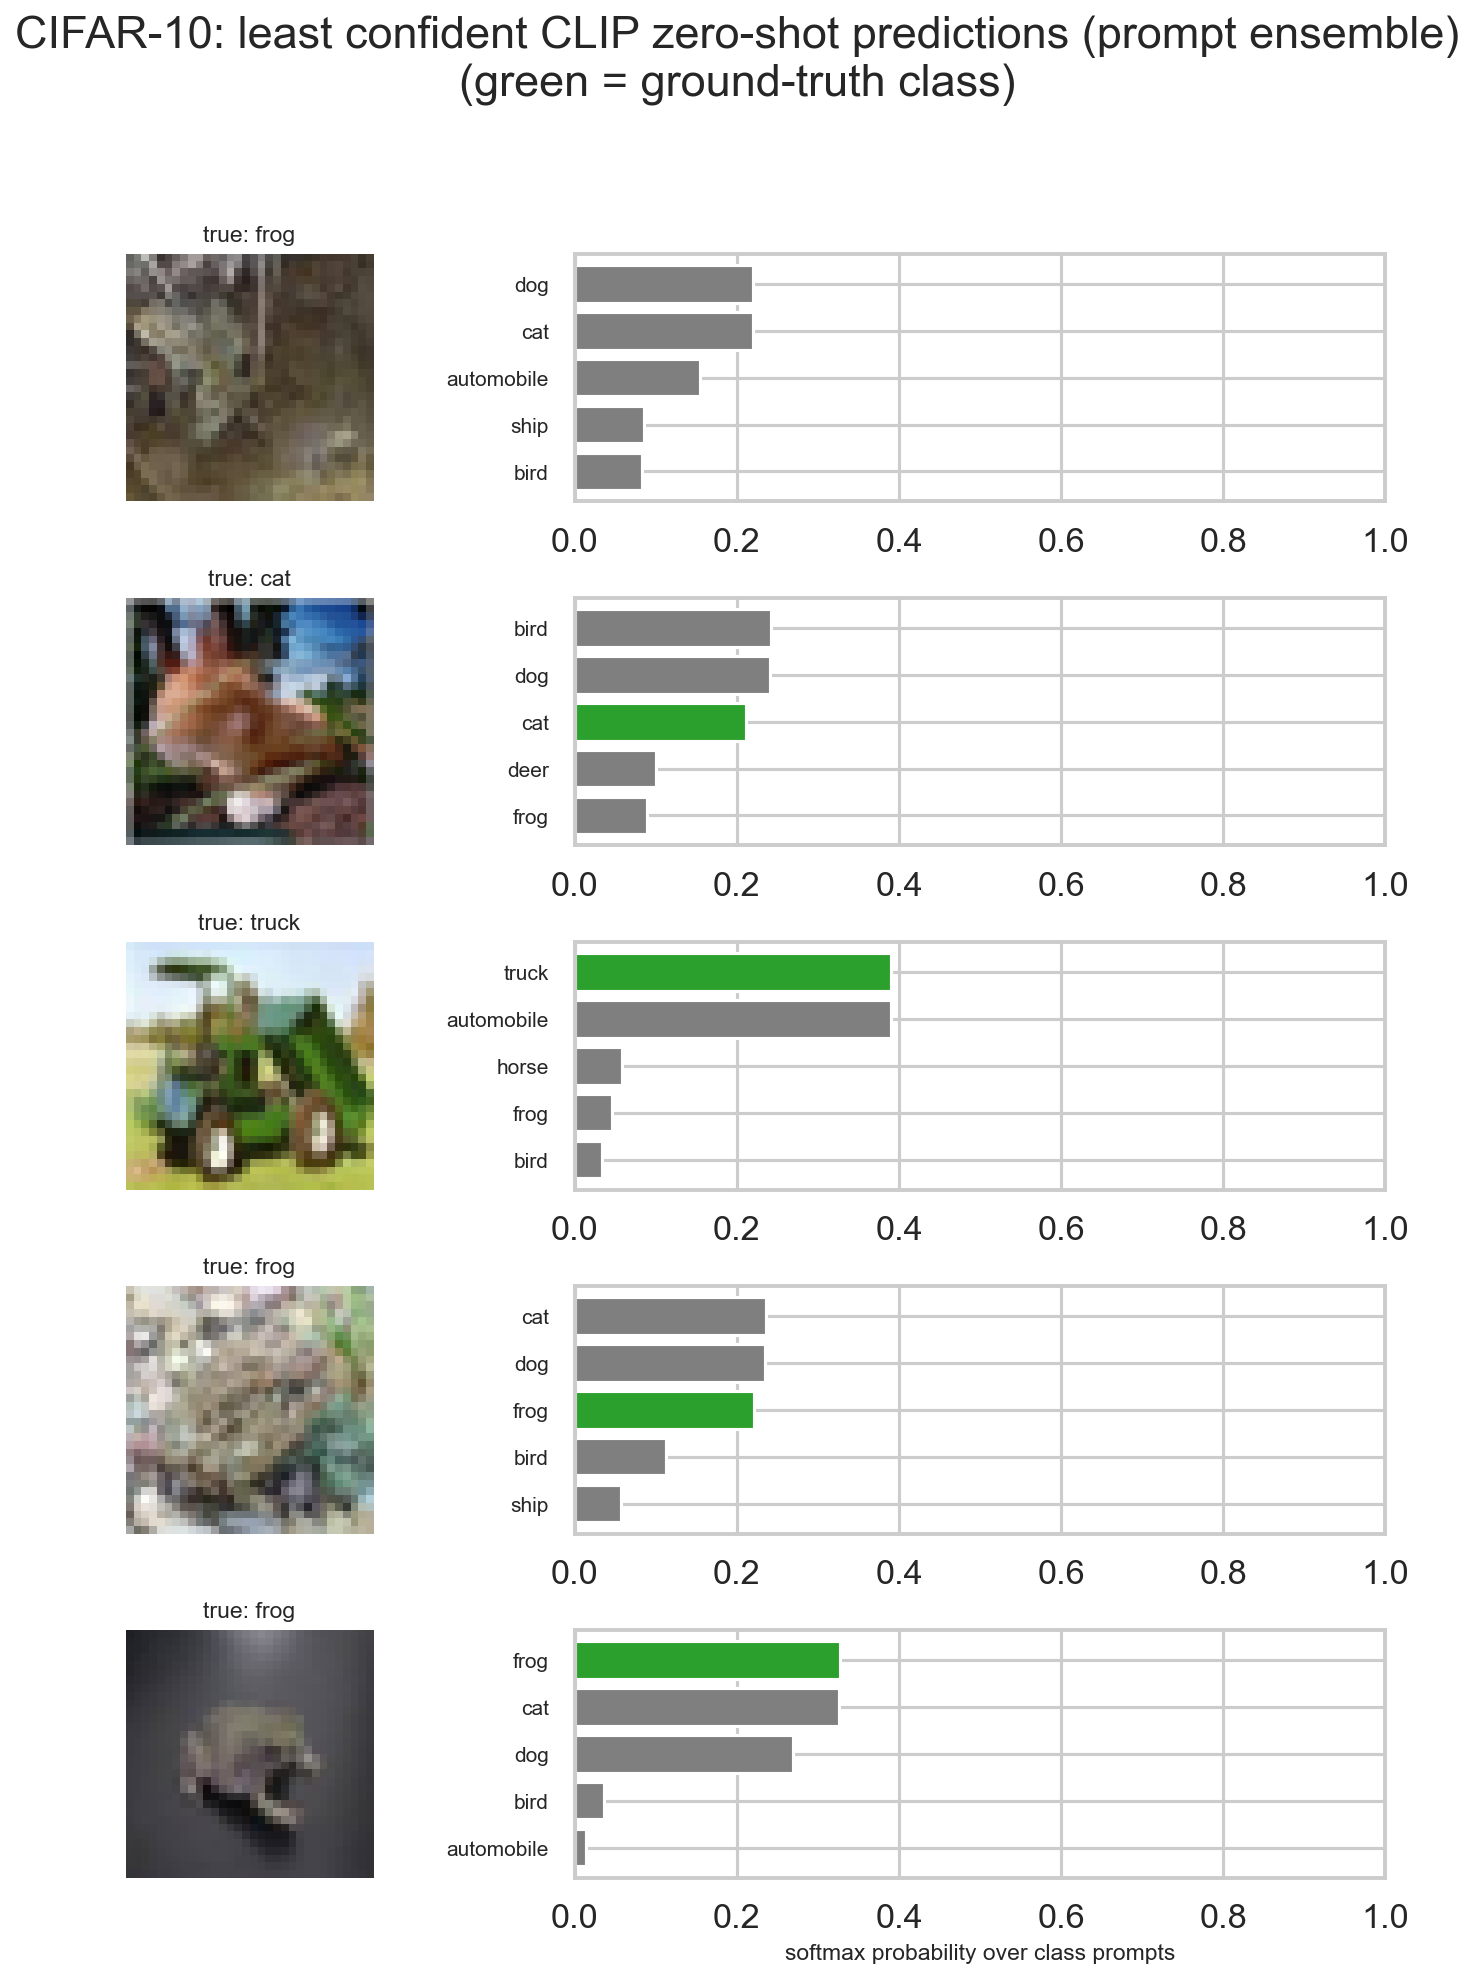

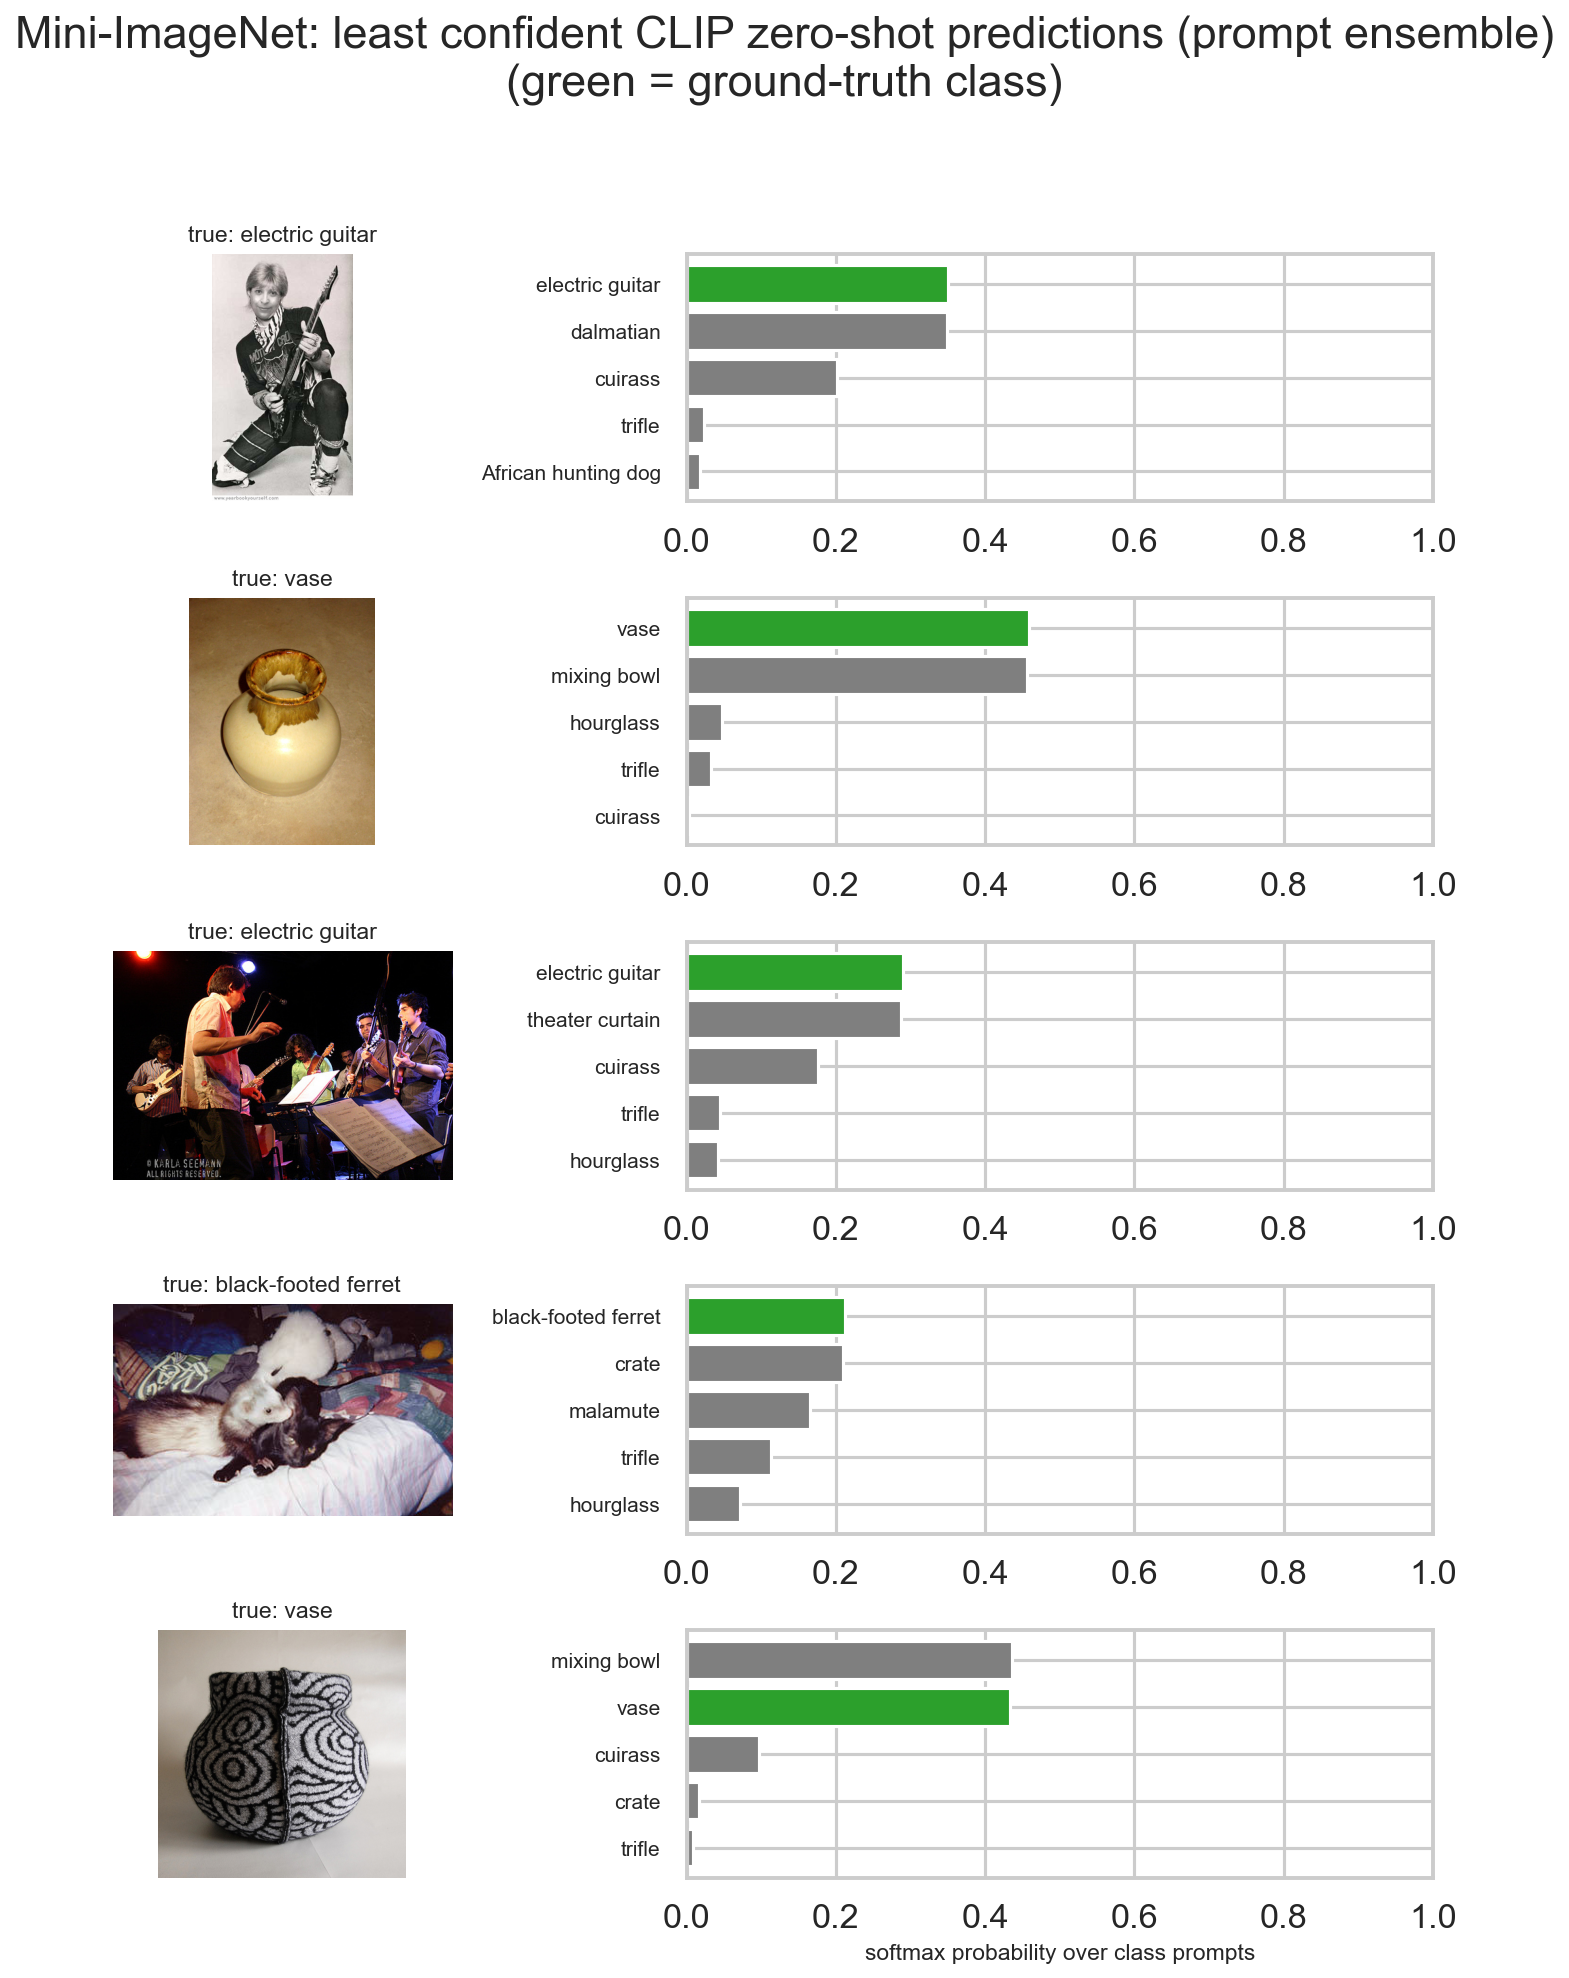

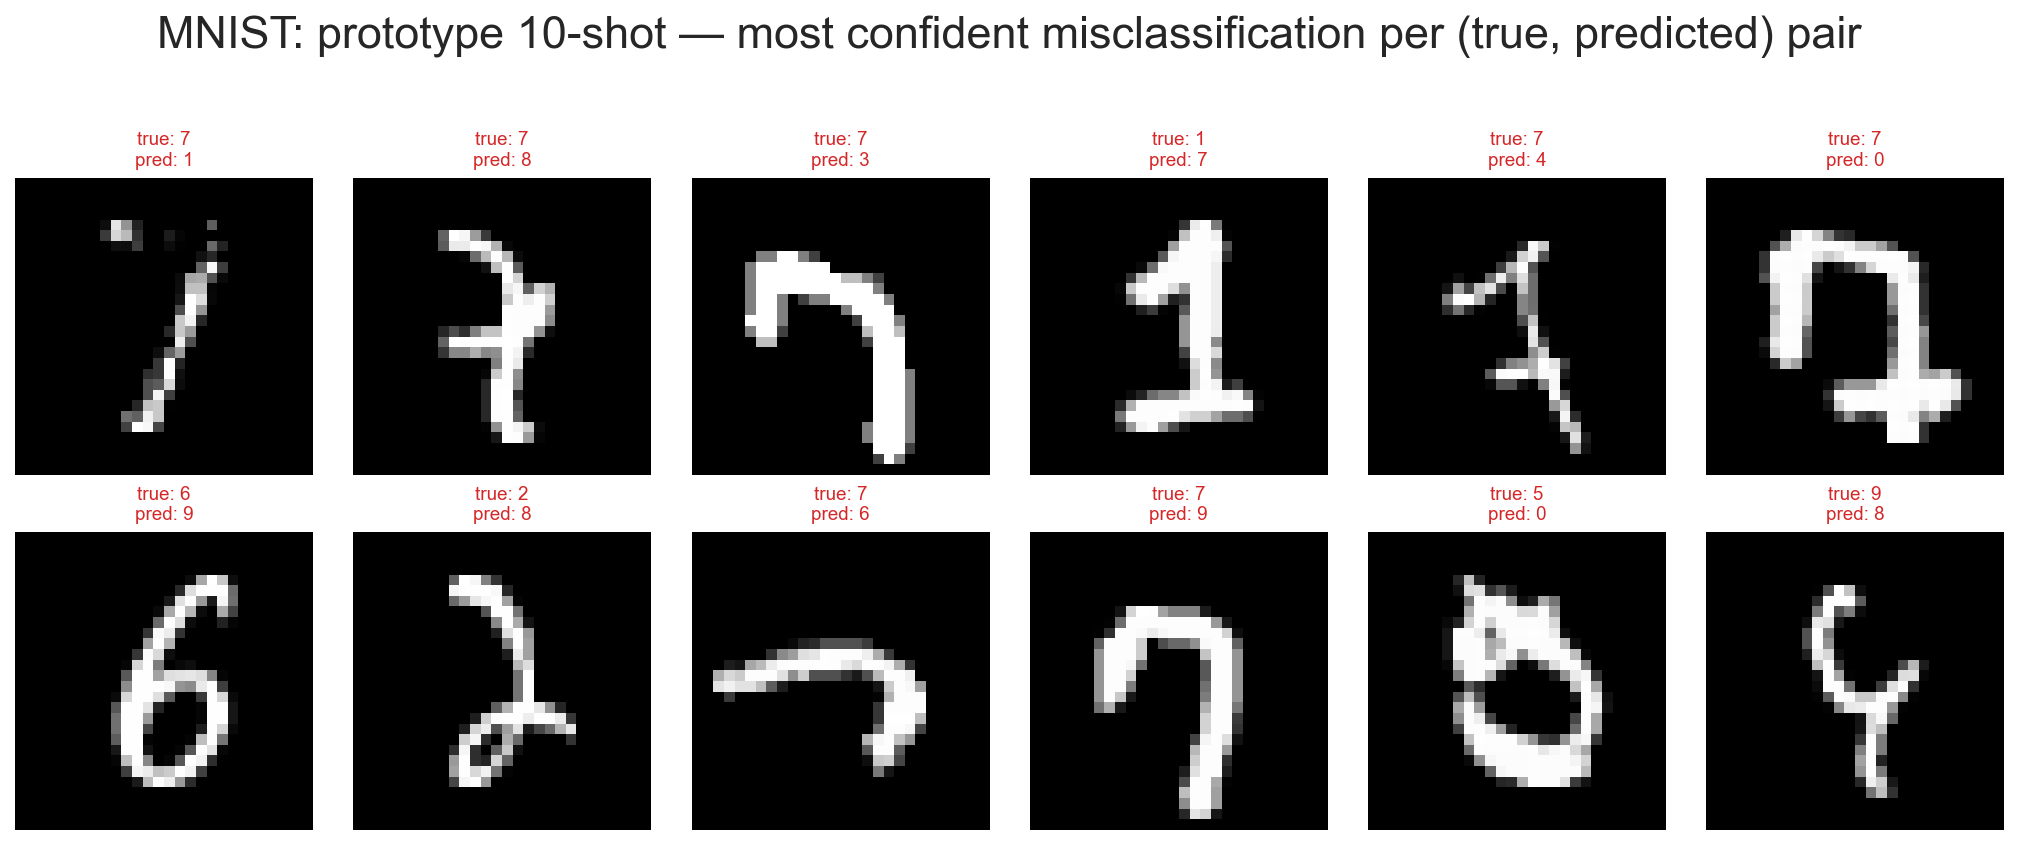

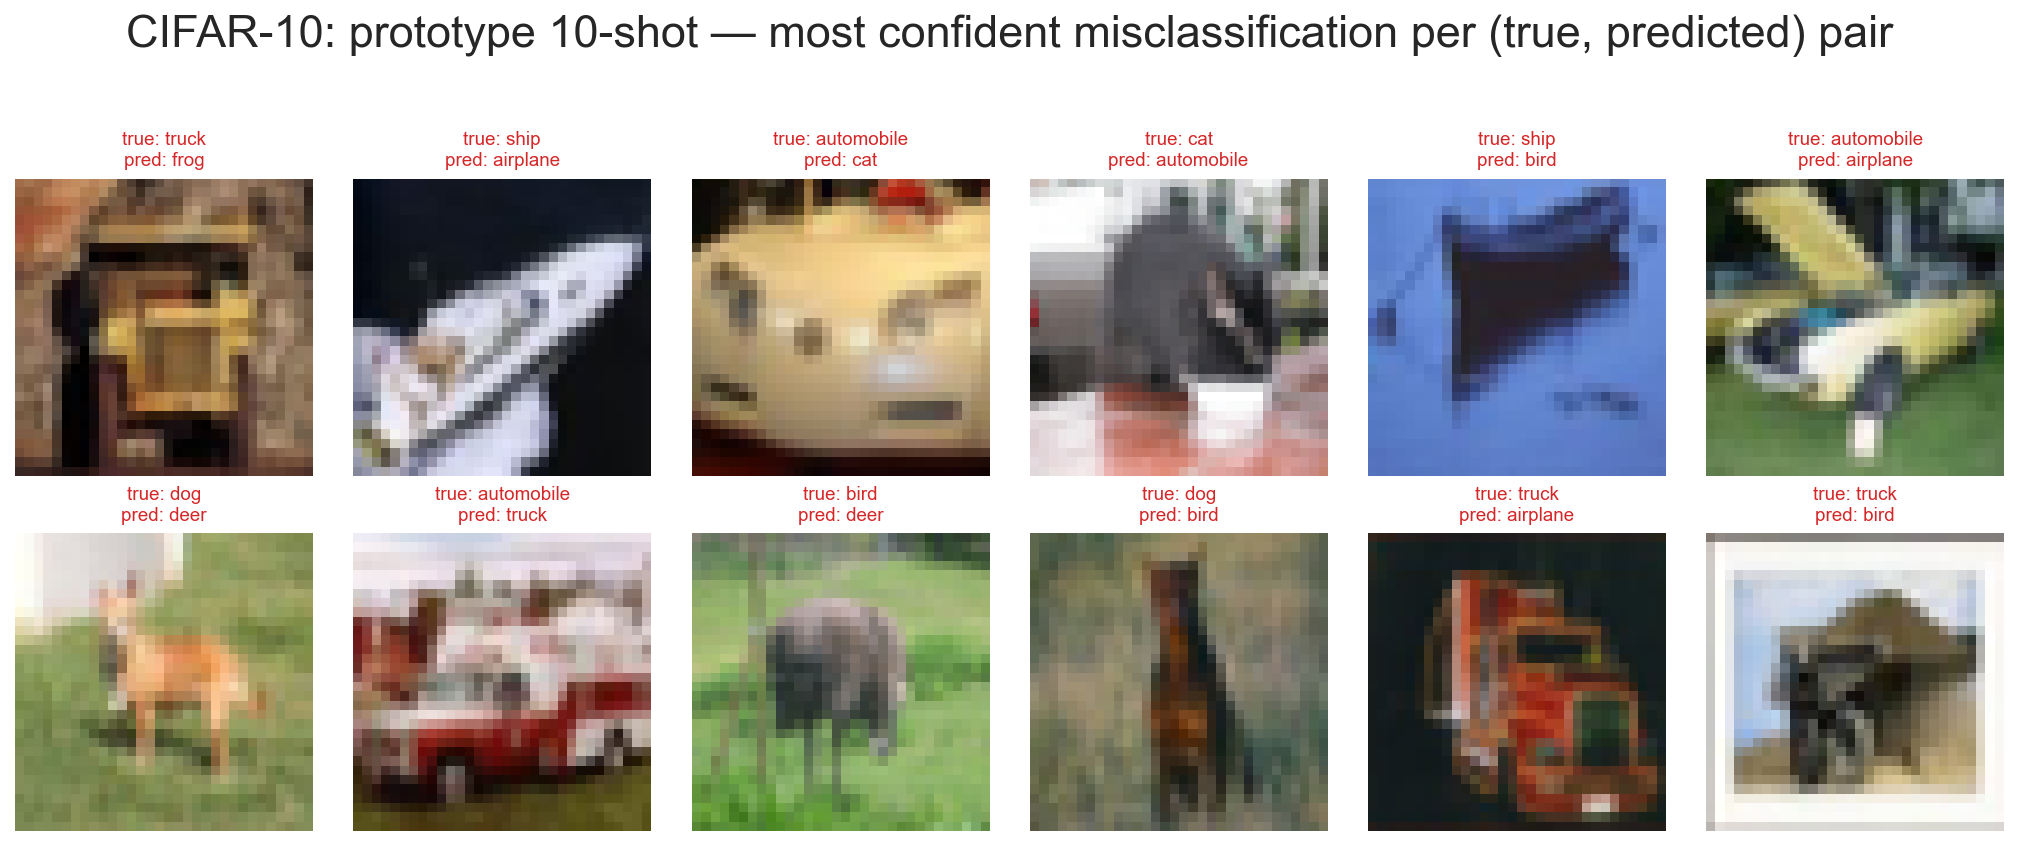

In [8]:
for name in ("confusion_mnist_proto10s.png", "confusion_cifar10_proto10s.png",
             "clip_zeroshot_cifar10.png", "clip_zeroshot_mini_imagenet.png",
             "failures_mnist.png", "failures_cifar10.png"):
    display(Image(str(REPO / "results" / "figures" / name), width=820))

## 6 · Discussion & handoff to Stage 2

Observations the tables above support (numbers auto-loaded from `results/metrics/`):

- **Frozen-embedding quality dominates.** Ranking across backbones follows embedding separability (§3) — the classifier head matters less than the encoder. Caveat: ResNet-50's near-perfect Mini-ImageNet scores reflect ImageNet-1k *label* overlap with the R&L test classes, not few-shot skill.
- **Zero-shot CLIP vs. MNIST.** CLIP zero-shot beats every CLIP-embedding head on natural images (CIFAR-10, Mini-ImageNet) but is markedly weaker on MNIST digits — handwritten digits are far from CLIP's training distribution, and the prompt ensemble even *hurts* there. A planned discussion point, not a bug.
- **Prototype vs. linear.** The trained probe beats the prototype at every dataset × K tested (paired per-episode CIs). The gap grows with K on MNIST but shrinks on CIFAR-10/Mini-ImageNet: with well-separated embeddings, class means become near-optimal at K=5.

**Artifacts handed to Stage 2/3** (all committed or reproducible via `tasks.ps1 extract`):

| Artifact | Path |
|---|---|
| Fixed episode indices | `results/artifacts/episodes/*.pt` |
| Class prototypes (per dataset/split/backbone) | `results/artifacts/prototypes_*.pt` |
| CLIP text embeddings (primary + ensemble) | `results/artifacts/clip_text_*.pt` |
| Cached embeddings | `results/features/*.pt` (regenerable) |

Stage 2 replaces the decision layer with a Flow-Matching transport toward prototypes / text embeddings; Stage 3 inserts FM before the linear head, trained end-to-end — both evaluated on the **same episode files** for an exact comparison.